# 01 — Analyse Exploratoire des Données (EDA)
## Projet PFE : Système Intelligent de Gestion de l'Eau — Grand Agadir

**Objectifs de ce notebook :**
1. Charger et inspecter le dataset
2. Analyser les distributions et statistiques descriptives
3. Visualiser les patterns temporels (saisonnalité, tendances)
4. Analyser la consommation par zone, quartier, compteur
5. Explorer les variables météo et leur corrélation avec la consommation
6. Analyser la distribution des anomalies et fuites
7. Préparer les insights pour guider la modélisation

---
## 0. Imports & Configuration

In [1]:
# ── Installation des dépendances (à lancer une seule fois) ──────────────────
import sys
!{sys.executable} -m pip install plotly statsmodels --quiet
print("✅ Dépendances installées")

✅ Dépendances installées



[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# ── Librairies standard ──────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
from pathlib import Path

# ── Visualisation ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Analyse temporelle ────────────────────────────────────────────────────────
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller

# ── Style global ─────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'figure.figsize': (14, 5),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

# ── Chemins ──────────────────────────────────────────────────────────────────
DATA_PATH = Path('../data/water_consumption_agadir_pfe.csv')
FIG_DIR   = Path('../reports/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('✅ Imports OK')

✅ Imports OK


---
## 1. Chargement & Inspection Initiale

In [3]:
# ── Chargement ───────────────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, parse_dates=['timestamp'])
print(f'\U0001f4c2 Chargé depuis : {DATA_PATH}')

# ── Nettoyage des noms de colonnes ───────────────────────────────────────────
df.columns = df.columns.str.strip().str.lower()

# S'assurer que timestamp est bien en datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values(['meterid', 'timestamp']).reset_index(drop=True)

print(f'\n\U0001f4d0 Shape : {df.shape}')
print(f'\U0001f4c5 Période : {df.timestamp.min()} \u2192 {df.timestamp.max()}')
print(f'\U0001f522 Compteurs : {df.meterid.nunique()}')
print(f'\U0001f5c2  Colonnes ({len(df.columns)}) :', list(df.columns))

📂 Chargé depuis : ..\data\water_consumption_agadir_pfe.csv

📐 Shape : (277644, 19)
📅 Période : 2025-02-01 00:00:00 → 2025-09-30 00:00:00
🔢 Compteurs : 12
🗂  Colonnes (19) : ['timestamp', 'meterid', 'zone', 'quartier', 'latitude', 'longitude', 'consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'rainfall', 'hour', 'dayofweek', 'month', 'isweekend', 'season', 'household_size', 'event_type', 'anomalylabel']


In [4]:
# ── Aperçu des premières lignes ───────────────────────────────────────────────
df.head()

,timestamp,meterid,zone,quartier,latitude,longitude,consumptionliters,flowratelpm,pressurebar,temperaturec,rainfall,hour,dayofweek,month,isweekend,season,household_size,event_type,anomalylabel
0,2025-02-01 00:00:00,M001,residential,Talborjt,30.42781,-9.593052,51.1,3.79,2.65,16.0,0.0,0,5,2,1,winter,3,normal,normal
1,2025-02-01 00:15:00,M001,residential,Talborjt,30.42781,-9.593052,85.9,5.39,2.67,14.7,0.0,0,5,2,1,winter,3,normal,normal
2,2025-02-01 00:30:00,M001,residential,Talborjt,30.42781,-9.593052,76.9,4.80,2.27,16.4,0.0,0,5,2,1,winter,3,normal,normal
3,2025-02-01 00:45:00,M001,residential,Talborjt,30.42781,-9.593052,102.6,6.62,2.46,15.6,0.0,0,5,2,1,winter,3,normal,normal
4,2025-02-01 01:00:00,M001,residential,Talborjt,30.42781,-9.593052,24.3,1.61,2.94,14.4,0.0,1,5,2,1,winter,3,normal,normal


In [5]:
# ── Types de données et valeurs manquantes ────────────────────────────────────
info = pd.DataFrame({
    'dtype'   : df.dtypes,
    'non_null': df.notna().sum(),
    'null'    : df.isna().sum(),
    'null_%'  : (df.isna().sum() / len(df) * 100).round(2),
    'nunique' : df.nunique()
})
display(info)

,dtype,non_null,null,null_%,nunique
timestamp,datetime64[ns],277644,0,0.0,23137
meterid,object,277644,0,0.0,12
zone,object,277644,0,0.0,3
quartier,object,277644,0,0.0,9
latitude,float64,277644,0,0.0,12
longitude,float64,277644,0,0.0,12
consumptionliters,float64,277644,0,0.0,20879
flowratelpm,float64,277644,0,0.0,15390
pressurebar,float64,277644,0,0.0,235
temperaturec,float64,277644,0,0.0,192


In [6]:
# ── Statistiques descriptives ─────────────────────────────────────────────────
df.describe().T.round(2)

,count,mean,min,25%,50%,75%,max,std
timestamp,277644,2025-06-01 12:00:00,2025-02-01 00:00:00,2025-04-02 06:00:00,2025-06-01 12:00:00,2025-07-31 18:00:00,2025-09-30 00:00:00,NaN
latitude,277644.0,30.406093,30.352405,30.396874,30.408391,30.427939,30.442525,0.027972
longitude,277644.0,-9.598588,-9.632039,-9.622401,-9.606932,-9.591169,-9.524726,0.033243
consumptionliters,277644.0,540.124451,0.5,195.2,390.25,756.8,17161.2,576.896294
flowratelpm,277644.0,36.001497,0.01,12.97,26.02,50.46,1195.91,38.567454
pressurebar,277644.0,2.485079,0.97,2.34,2.5,2.65,3.48,0.250791
temperaturec,277644.0,21.362225,10.6,17.9,21.6,24.9,30.7,3.993713
rainfall,277644.0,0.000721,0.0,0.0,0.0,0.0,1.19,0.019085
hour,277644.0,11.499503,0.0,5.0,11.0,17.0,23.0,6.922462
dayofweek,277644.0,3.008212,0.0,1.0,3.0,5.0,6.0,2.010333


---
## 2. Distribution de la Variable Cible : `consumptionliters`

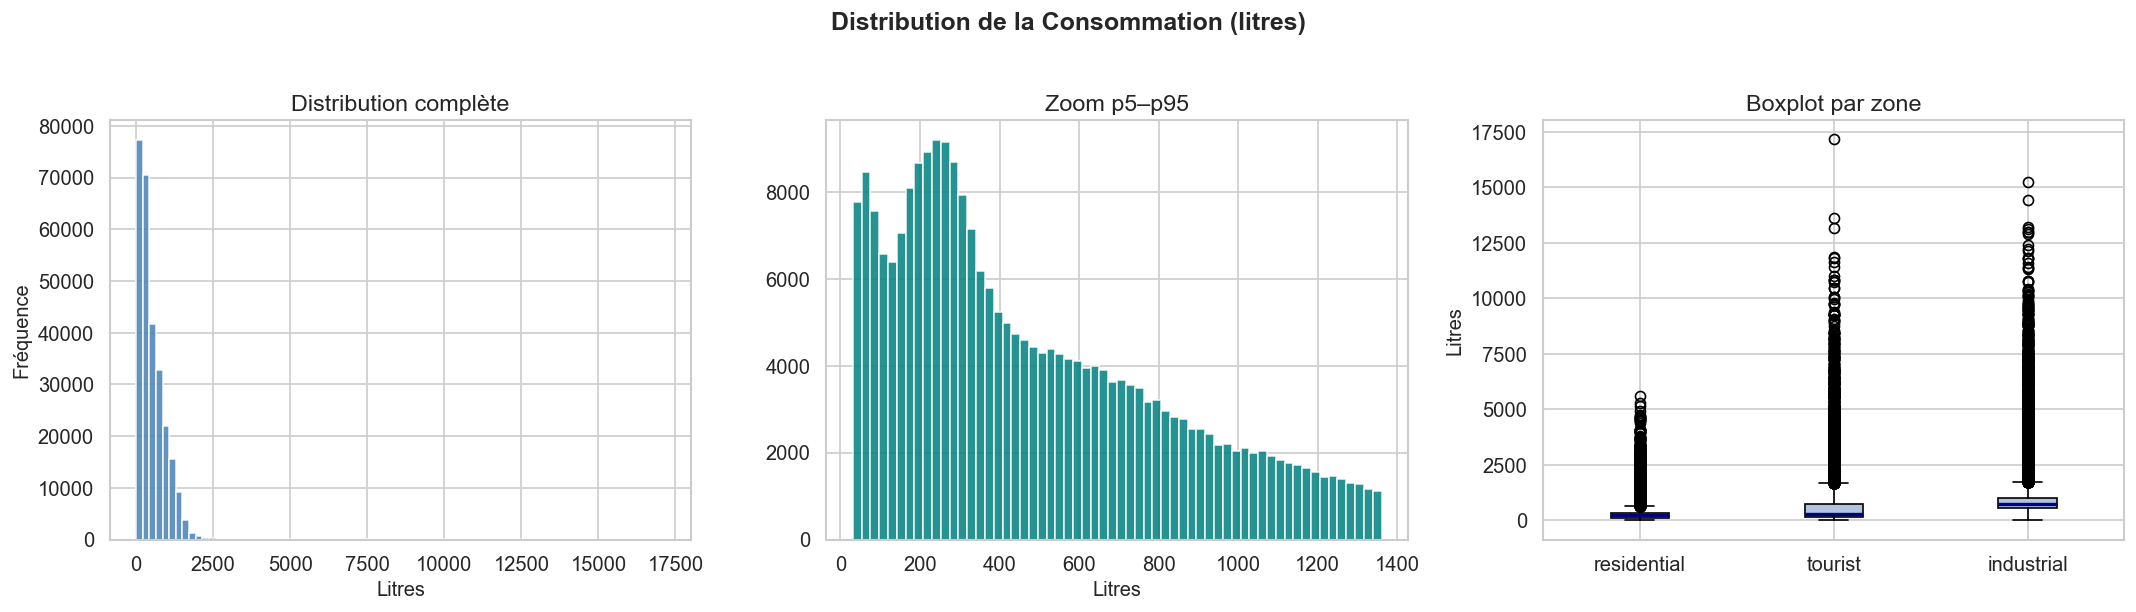

Skewness : 5.546
Kurtosis : 65.694


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogramme complet
axes[0].hist(df['consumptionliters'], bins=80, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_title('Distribution complète')
axes[0].set_xlabel('Litres')
axes[0].set_ylabel('Fréquence')

# Sans les extrêmes (zoom p5–p95)
p5, p95 = df['consumptionliters'].quantile([0.05, 0.95])
df_zoom = df.loc[df['consumptionliters'].between(p5, p95), 'consumptionliters']
axes[1].hist(df_zoom, bins=60, color='teal', edgecolor='white', alpha=0.85)
axes[1].set_title('Zoom p5–p95')
axes[1].set_xlabel('Litres')

# Boxplot par zone
zones = df['zone'].unique()
data_bp = [df.loc[df['zone'] == z, 'consumptionliters'].values for z in zones]
bp = axes[2].boxplot(data_bp, labels=zones, patch_artist=True,
                     boxprops=dict(facecolor='lightsteelblue'),
                     medianprops=dict(color='navy', linewidth=2))
axes[2].set_title('Boxplot par zone')
axes[2].set_ylabel('Litres')

plt.suptitle('Distribution de la Consommation (litres)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig01_distribution_consommation.png', bbox_inches='tight')
plt.show()

print(f"Skewness : {df['consumptionliters'].skew():.3f}")
print(f"Kurtosis : {df['consumptionliters'].kurtosis():.3f}")

---
## 3. Analyse Temporelle — Série Globale

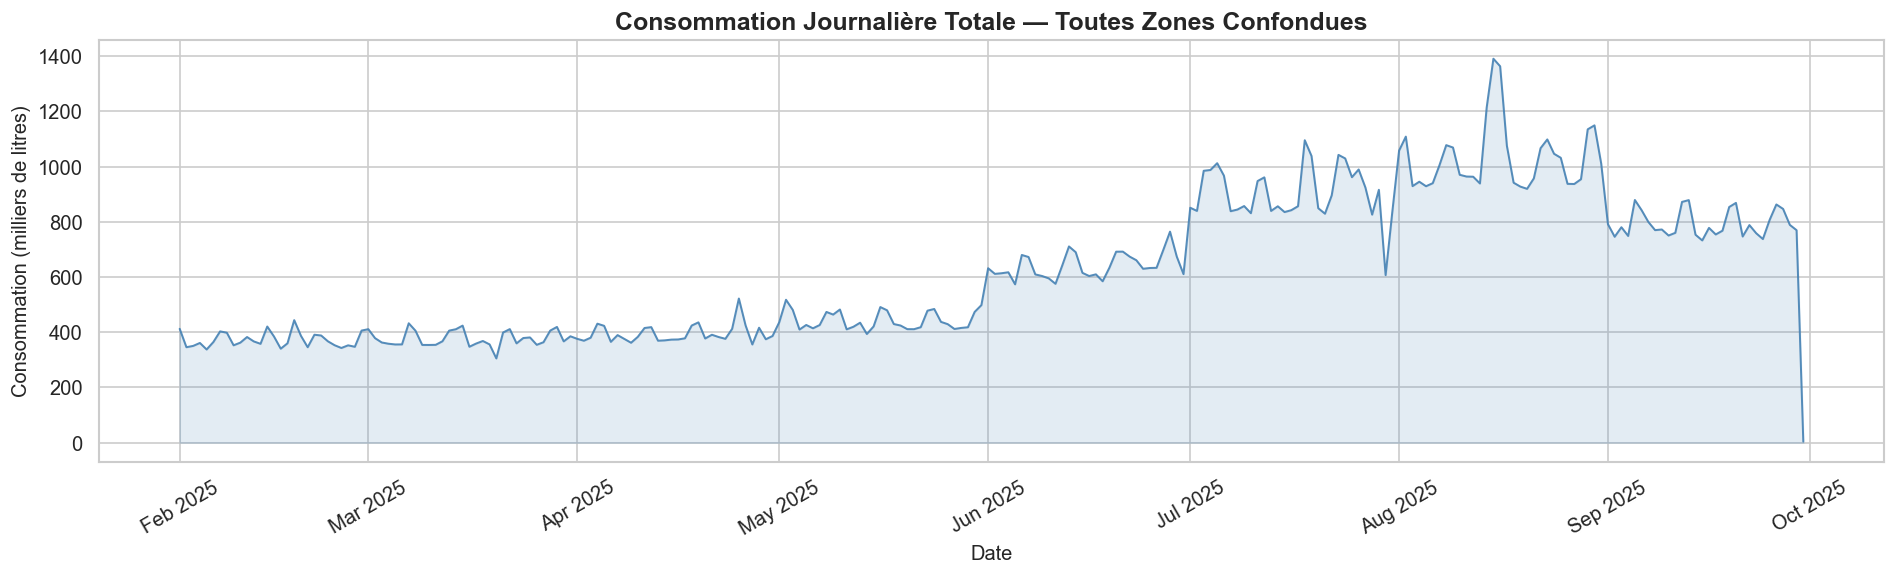

In [8]:
# ── Agrégation journalière (toutes zones confondues) ──────────────────────────
daily = (
    df.groupby(df['timestamp'].dt.date)['consumptionliters']
      .sum()
      .reset_index()
)
daily.columns = ['date', 'total_liters']
daily['date'] = pd.to_datetime(daily['date'])
daily = daily.sort_values('date')

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(daily['date'], daily['total_liters'] / 1000, color='steelblue', linewidth=1.2, alpha=0.9)
ax.fill_between(daily['date'], daily['total_liters'] / 1000, alpha=0.15, color='steelblue')
ax.set_title('Consommation Journalière Totale — Toutes Zones Confondues', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation (milliers de litres)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.xaxis.set_major_locator(mdates.MonthLocator())
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig02_serie_temporelle_journaliere.png', bbox_inches='tight')
plt.show()

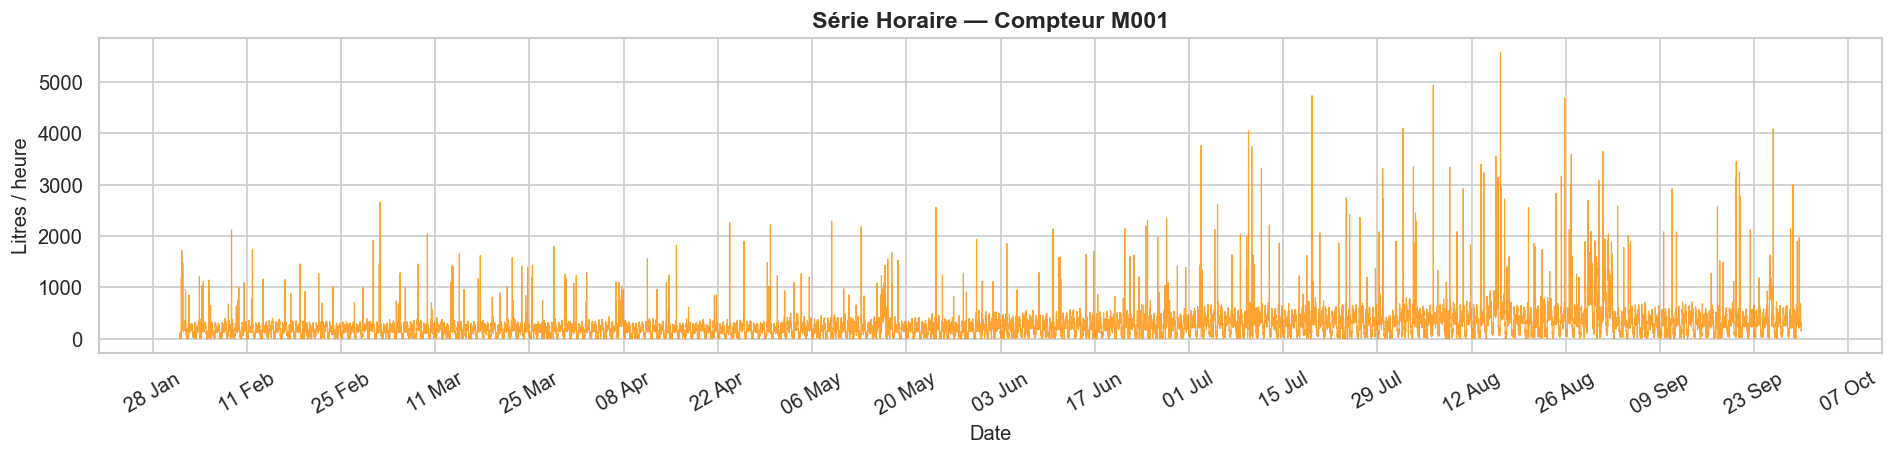

In [9]:
# ── Série horaire pour un compteur (exemple visuel) ───────────────────────────
sample_meter = df['meterid'].unique()[0]
df_meter = df[df['meterid'] == sample_meter].copy()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(df_meter['timestamp'], df_meter['consumptionliters'], color='darkorange',
        linewidth=0.7, alpha=0.8)
ax.set_title(f'Série Horaire — Compteur {sample_meter}', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig03_serie_horaire_compteur.png', bbox_inches='tight')
plt.show()

---
## 4. Patterns Cycliques — Heure, Jour, Mois

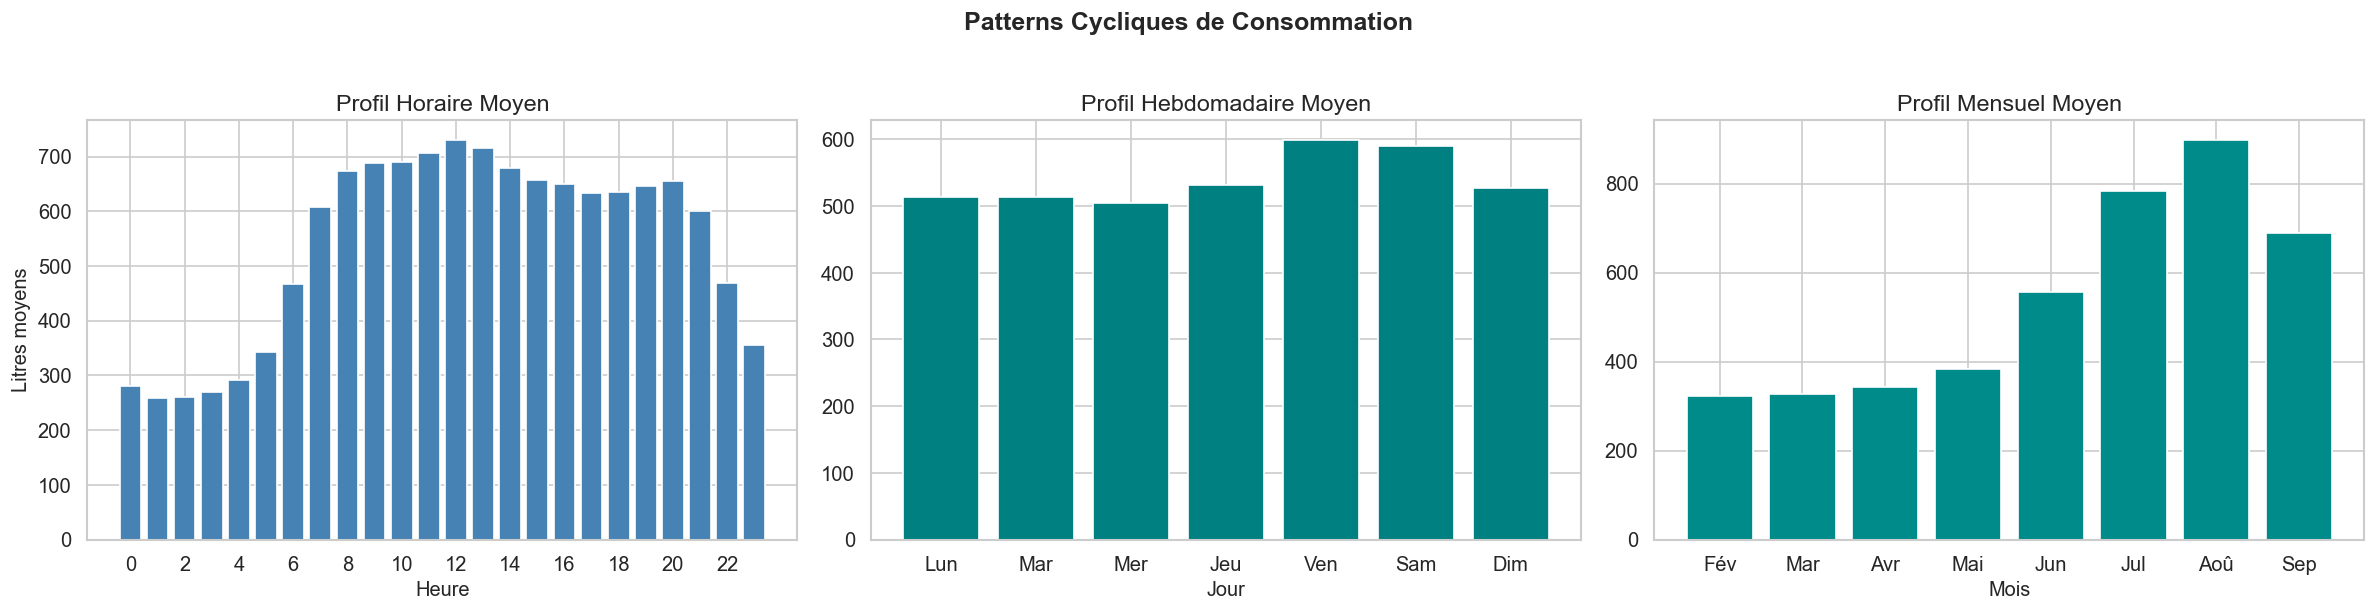

In [10]:
# ── Profil horaire moyen ───────────────────────────────────────────────────────
hourly_profile = df.groupby('hour')['consumptionliters'].mean()

# ── Profil jour de semaine ────────────────────────────────────────────────────
day_labels = ['Lun', 'Mar', 'Mer', 'Jeu', 'Ven', 'Sam', 'Dim']
daily_profile = df.groupby('dayofweek')['consumptionliters'].mean()

# ── Profil mensuel ────────────────────────────────────────────────────────────
month_labels = ['Fév', 'Mar', 'Avr', 'Mai', 'Jun', 'Jul', 'Aoû', 'Sep']
monthly_profile = df.groupby('month')['consumptionliters'].mean()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Heure
axes[0].bar(hourly_profile.index, hourly_profile.values, color='steelblue', edgecolor='white')
axes[0].set_title('Profil Horaire Moyen')
axes[0].set_xlabel('Heure')
axes[0].set_ylabel('Litres moyens')
axes[0].set_xticks(range(0, 24, 2))

# Jour
axes[1].bar(range(7), daily_profile.values, color='teal', edgecolor='white')
axes[1].set_title('Profil Hebdomadaire Moyen')
axes[1].set_xlabel('Jour')
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(day_labels)

# Mois
axes[2].bar(range(len(monthly_profile)), monthly_profile.values, color='darkcyan', edgecolor='white')
axes[2].set_title('Profil Mensuel Moyen')
axes[2].set_xlabel('Mois')
axes[2].set_xticks(range(len(monthly_profile)))
axes[2].set_xticklabels(month_labels)

plt.suptitle('Patterns Cycliques de Consommation', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig04_patterns_cycliques.png', bbox_inches='tight')
plt.show()

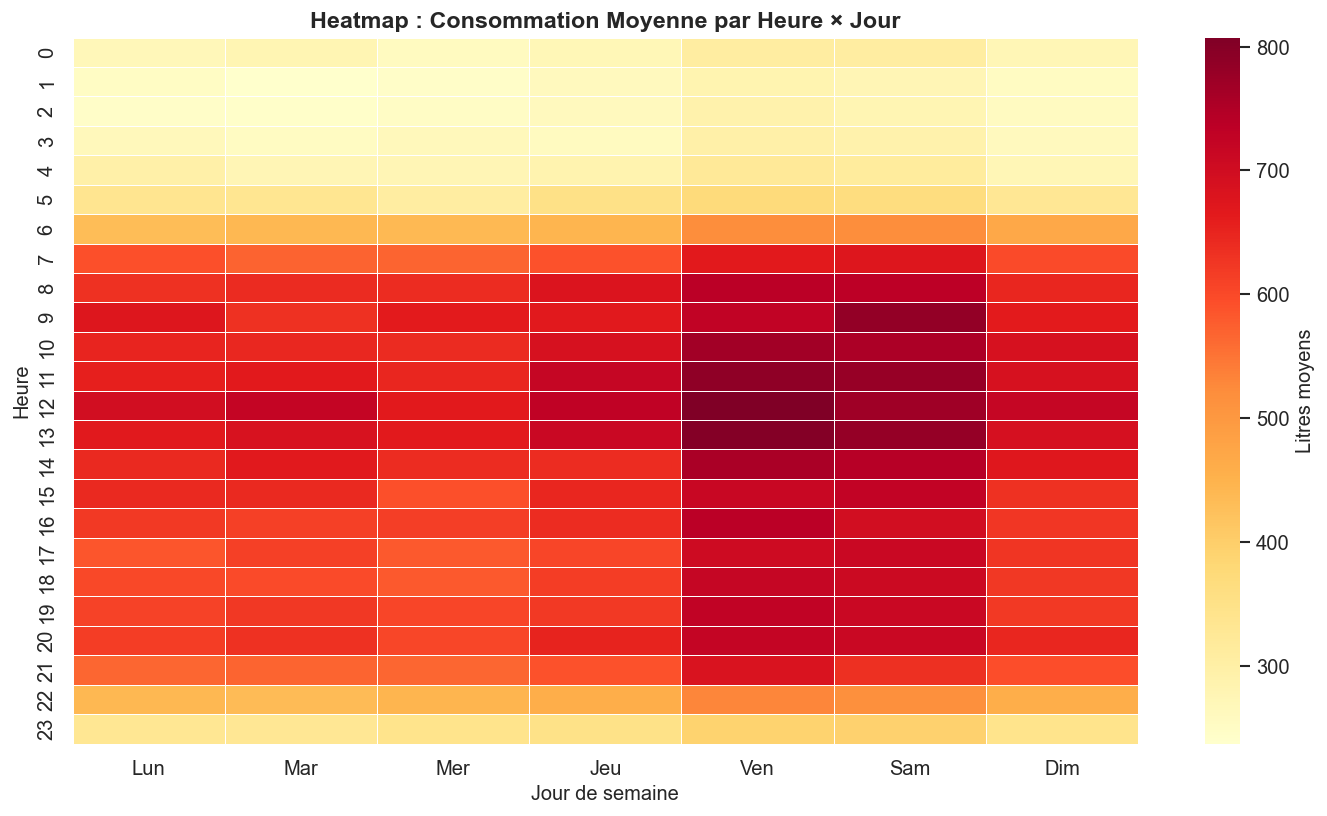

In [11]:
# ── Heatmap heure × jour de semaine ──────────────────────────────────────────
pivot_hw = df.pivot_table(
    values='consumptionliters', index='hour', columns='dayofweek', aggfunc='mean'
)
pivot_hw.columns = day_labels

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    pivot_hw, cmap='YlOrRd', linewidths=0.3,
    annot=False, fmt='.0f', ax=ax,
    cbar_kws={'label': 'Litres moyens'}
)
ax.set_title('Heatmap : Consommation Moyenne par Heure × Jour', fontsize=14, fontweight='bold')
ax.set_xlabel('Jour de semaine')
ax.set_ylabel('Heure')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig05_heatmap_heure_jour.png', bbox_inches='tight')
plt.show()

---
## 5. Analyse par Zone et Quartier


📊 Statistiques par zone :


,Moyenne,Médiane,Std,Total
zone,,,,
industrial,858.50,739.70,636.35,79452891.2
tourist,499.02,299.95,593.90,46183307.6
residential,262.85,227.20,246.65,24326114.3


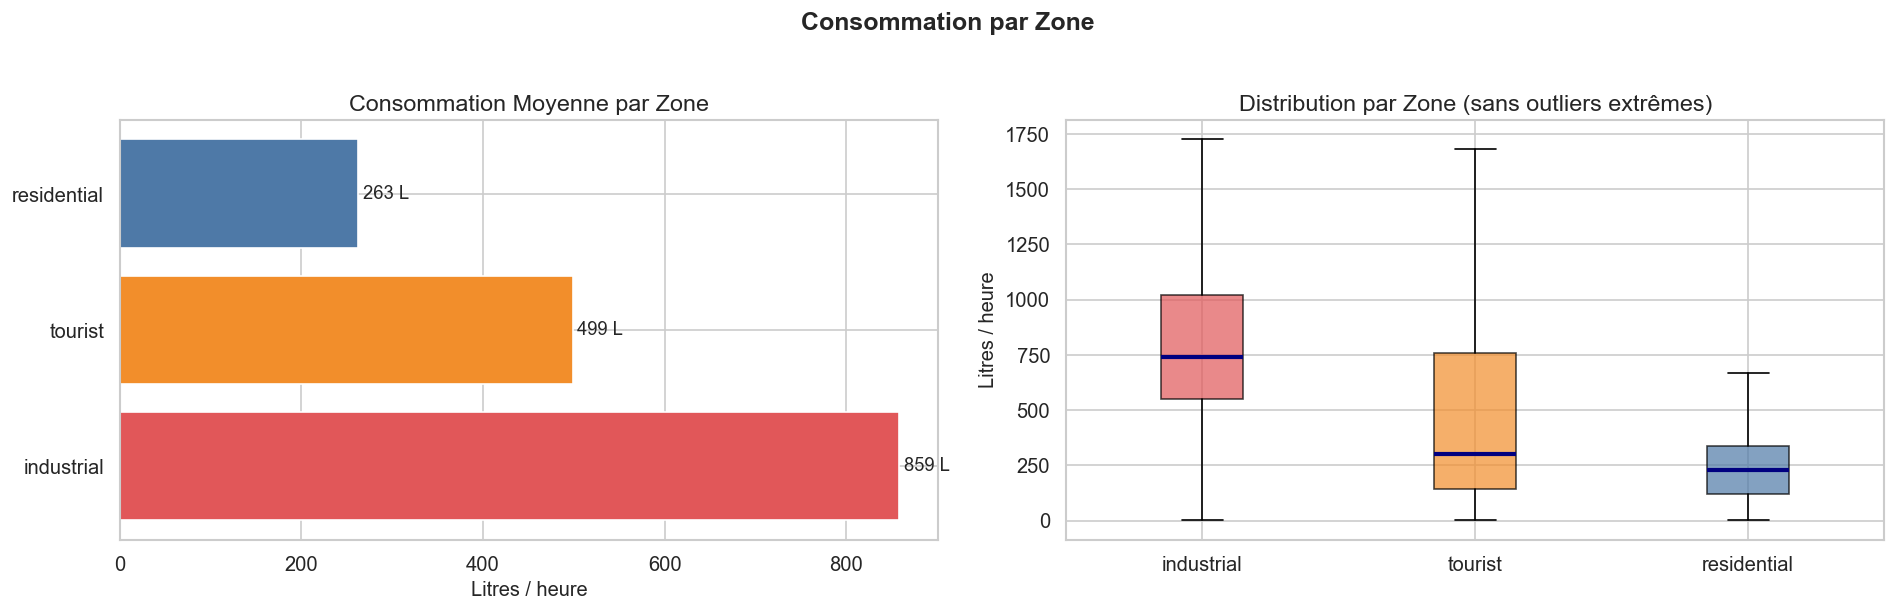

In [12]:
# ── Consommation moyenne par zone ─────────────────────────────────────────────
zone_stats = (
    df.groupby('zone')['consumptionliters']
      .agg(['mean', 'median', 'std', 'sum'])
      .rename(columns={'mean':'Moyenne', 'median':'Médiane', 'std':'Std', 'sum':'Total'})
      .sort_values('Moyenne', ascending=False)
)
print('\n📊 Statistiques par zone :')
display(zone_stats.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Bar chart — moyenne
colors = {'residential': '#4E79A7', 'tourist': '#F28E2B', 'industrial': '#E15759'}
zone_colors = [colors.get(z, 'grey') for z in zone_stats.index]
axes[0].barh(zone_stats.index, zone_stats['Moyenne'], color=zone_colors, edgecolor='white')
axes[0].set_title('Consommation Moyenne par Zone')
axes[0].set_xlabel('Litres / heure')
for i, (v, lbl) in enumerate(zip(zone_stats['Moyenne'], zone_stats.index)):
    axes[0].text(v + 5, i, f'{v:.0f} L', va='center', fontsize=11)

# Boxplot
zone_data = [df.loc[df['zone'] == z, 'consumptionliters'].values for z in zone_stats.index]
bp = axes[1].boxplot(zone_data, labels=zone_stats.index, patch_artist=True,
                     showfliers=False,
                     boxprops=dict(facecolor='lightsteelblue'),
                     medianprops=dict(color='navy', linewidth=2.5))
for patch, color in zip(bp['boxes'], zone_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution par Zone (sans outliers extrêmes)')
axes[1].set_ylabel('Litres / heure')

plt.suptitle('Consommation par Zone', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig06_consommation_zone.png', bbox_inches='tight')
plt.show()

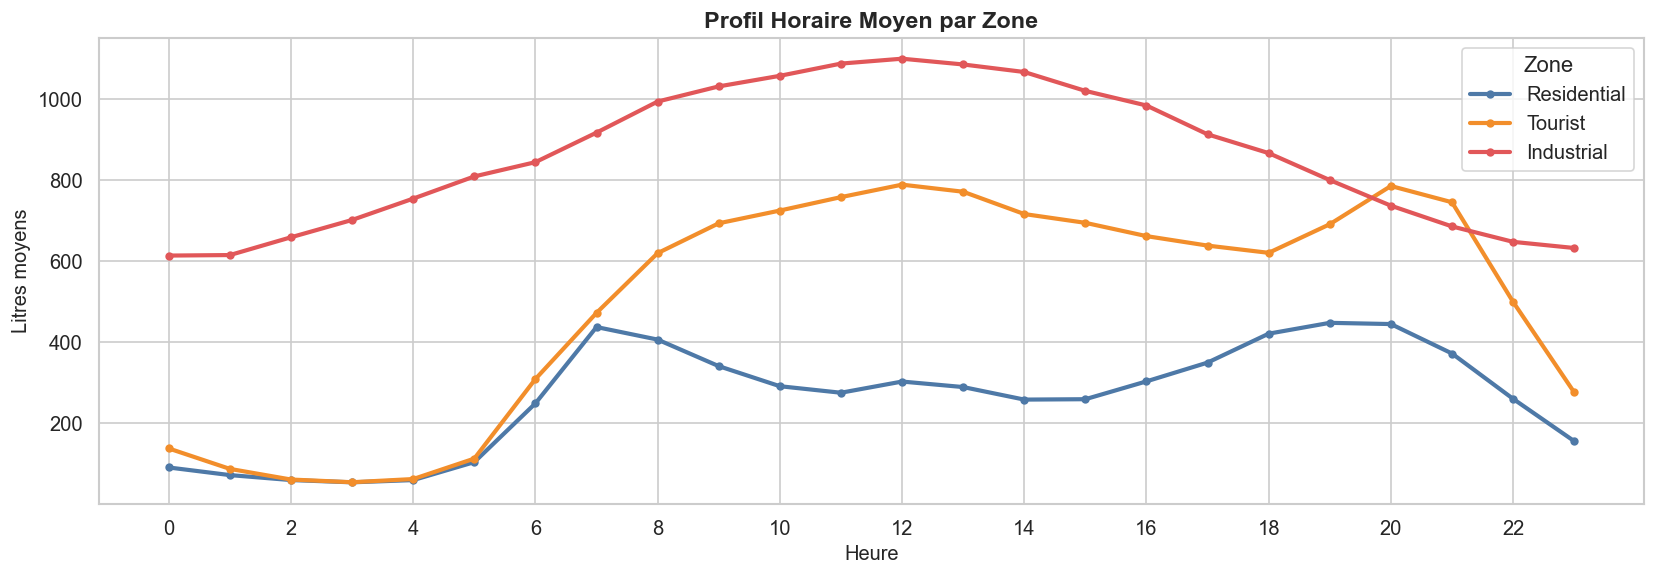

In [13]:
# ── Profil horaire par zone ────────────────────────────────────────────────────
hourly_zone = df.groupby(['hour', 'zone'])['consumptionliters'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
for zone, color in colors.items():
    mask = hourly_zone['zone'] == zone
    ax.plot(hourly_zone.loc[mask, 'hour'], hourly_zone.loc[mask, 'consumptionliters'],
            label=zone.capitalize(), color=color, linewidth=2.5, marker='o', markersize=4)
ax.set_title('Profil Horaire Moyen par Zone', fontsize=14, fontweight='bold')
ax.set_xlabel('Heure')
ax.set_ylabel('Litres moyens')
ax.set_xticks(range(0, 24, 2))
ax.legend(title='Zone')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig07_profil_horaire_zone.png', bbox_inches='tight')
plt.show()

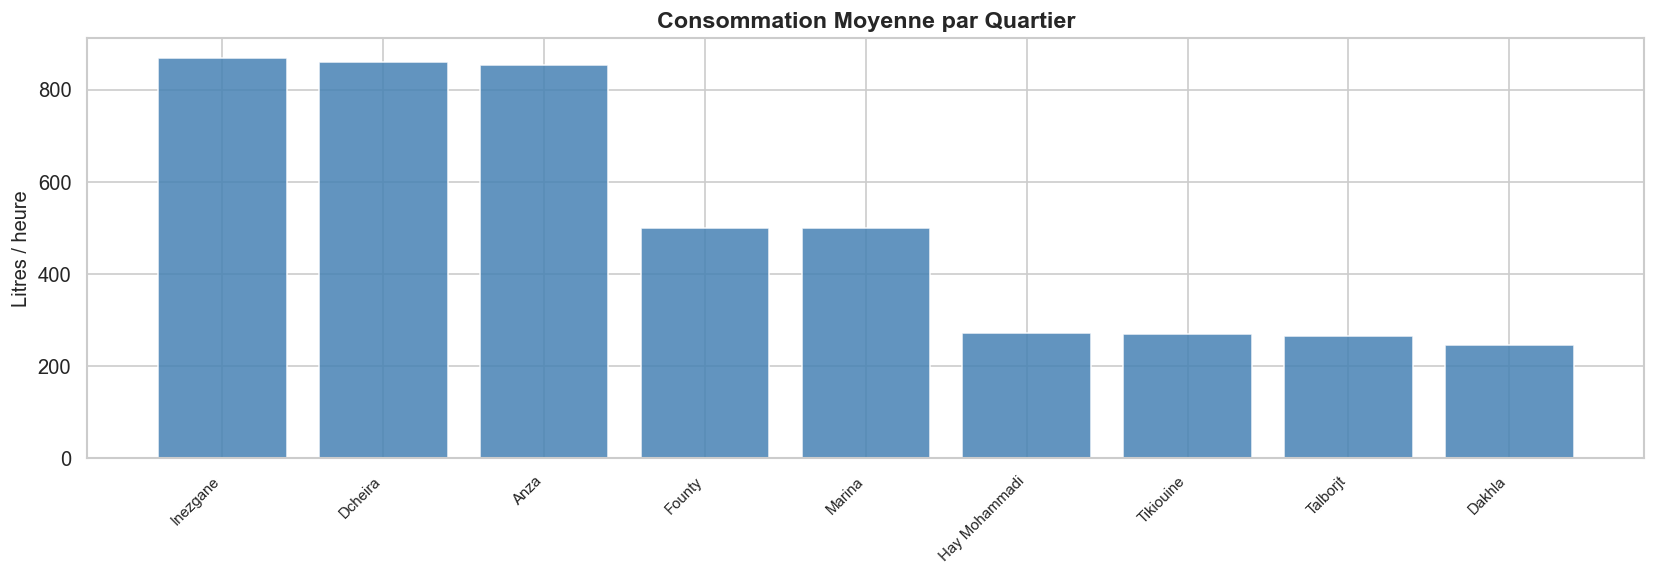

In [14]:
# ── Consommation par quartier ─────────────────────────────────────────────────
if 'quartier' in df.columns:
    quartier_stats = (
        df.groupby('quartier')['consumptionliters']
          .mean()
          .sort_values(ascending=False)
    )

    fig, ax = plt.subplots(figsize=(14, 5))
    bars = ax.bar(range(len(quartier_stats)), quartier_stats.values,
                  color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_xticks(range(len(quartier_stats)))
    ax.set_xticklabels(quartier_stats.index, rotation=45, ha='right', fontsize=9)
    ax.set_title('Consommation Moyenne par Quartier', fontsize=14, fontweight='bold')
    ax.set_ylabel('Litres / heure')
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig08_consommation_quartier.png', bbox_inches='tight')
    plt.show()
else:
    print('⚠️  Colonne quartier non trouvée')

---
## 6. Variables Météorologiques & Corrélations

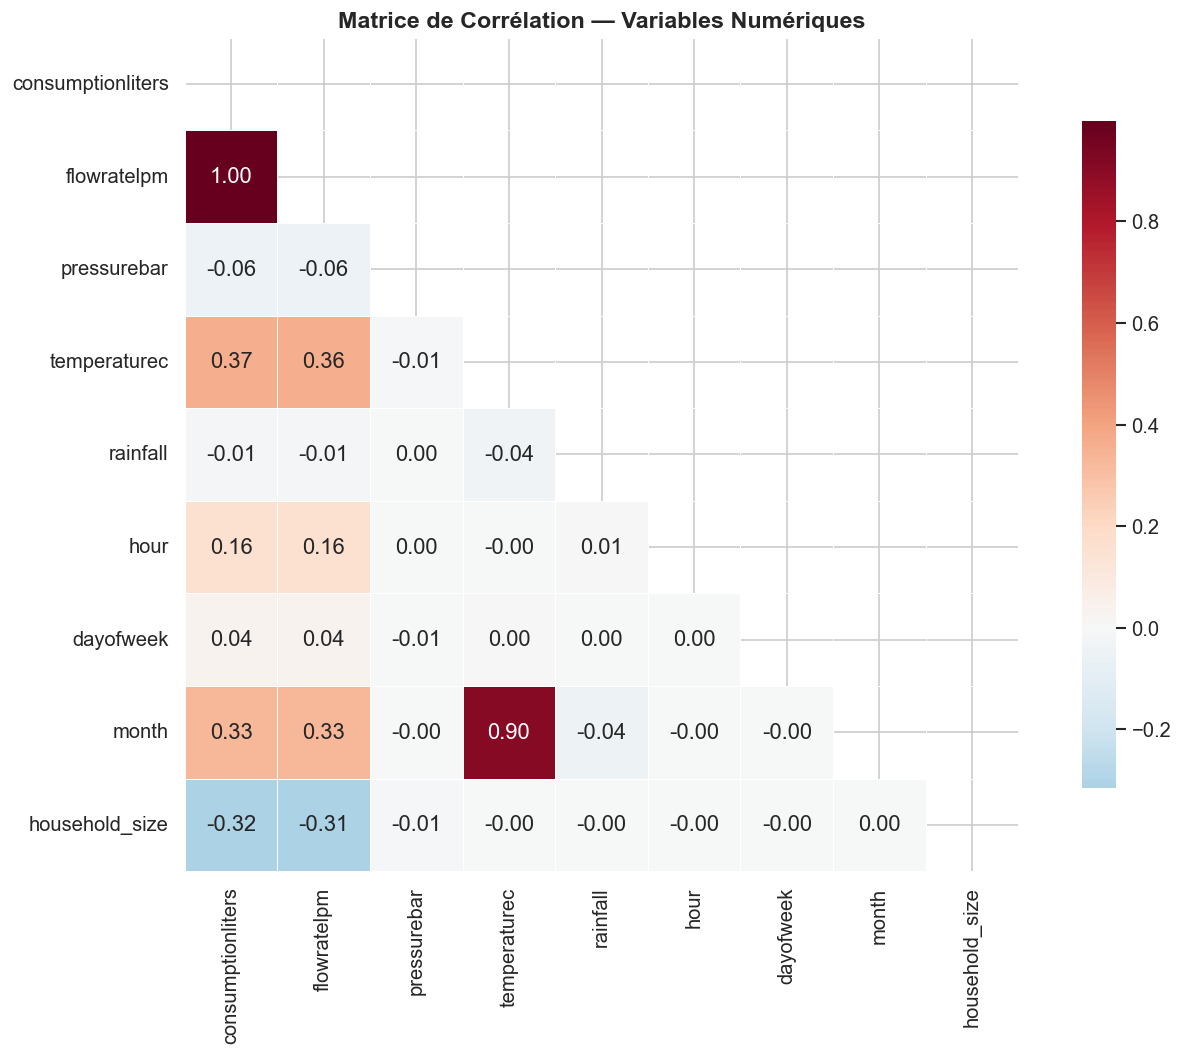

In [15]:
# ── Corrélation générale ──────────────────────────────────────────────────────
num_cols = ['consumptionliters', 'flowratelpm', 'pressurebar',
            'temperaturec', 'rainfall', 'hour', 'dayofweek', 'month',
            'household_size' if 'household_size' in df.columns else 'householdsize'
            if 'householdsize' in df.columns else None]
num_cols = [c for c in num_cols if c and c in df.columns]

corr = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, cmap='RdBu_r', center=0,
    annot=True, fmt='.2f', linewidths=0.5,
    square=True, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Matrice de Corrélation — Variables Numériques', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig09_matrice_correlation.png', bbox_inches='tight')
plt.show()

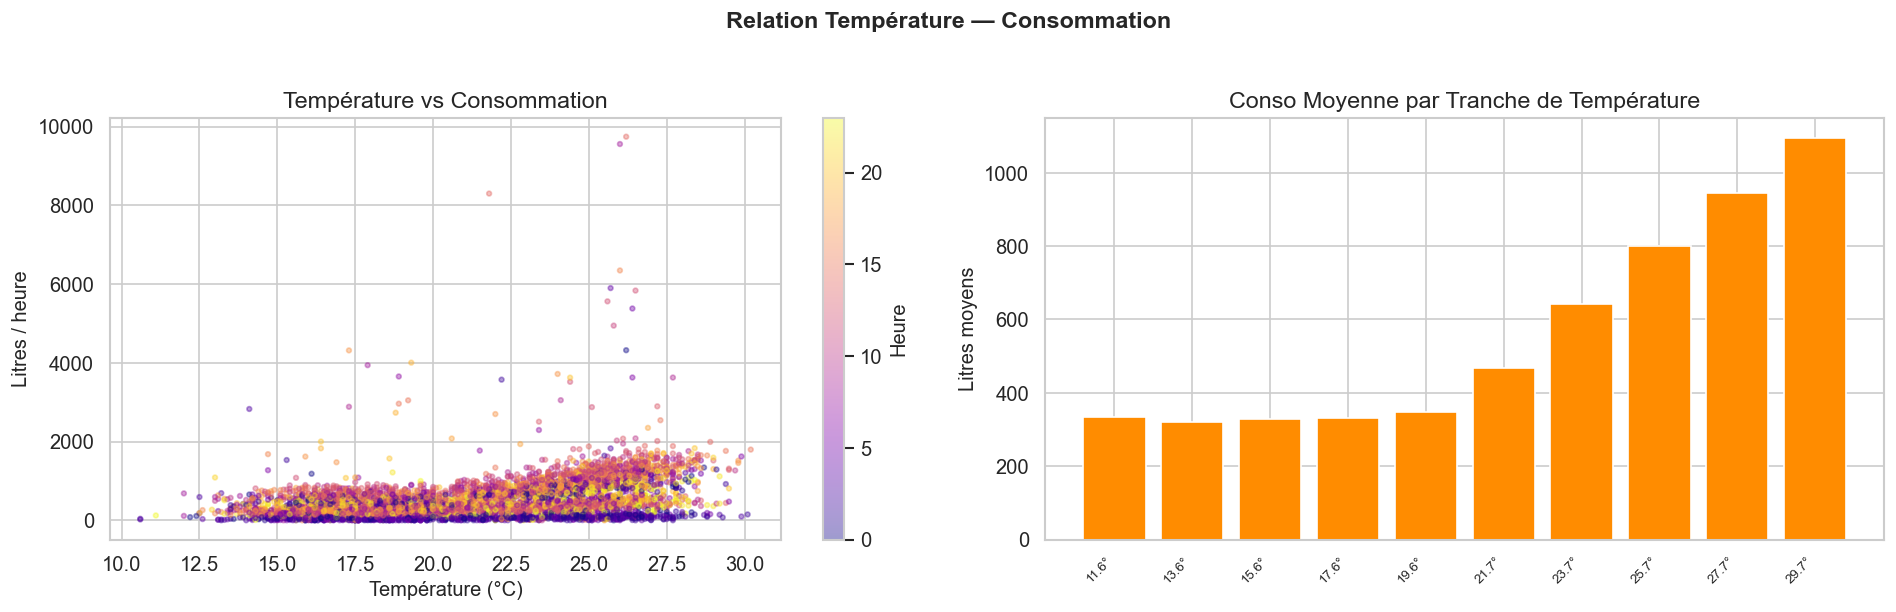

In [16]:
# ── Température vs Consommation ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Scatter (échantillon)
sample = df.sample(min(5000, len(df)), random_state=42)
sc = axes[0].scatter(
    sample['temperaturec'], sample['consumptionliters'],
    c=sample['hour'], cmap='plasma', alpha=0.4, s=8
)
plt.colorbar(sc, ax=axes[0], label='Heure')
axes[0].set_title('Température vs Consommation')
axes[0].set_xlabel('Température (°C)')
axes[0].set_ylabel('Litres / heure')

# Conso moyenne par tranche de température
df['temp_bin'] = pd.cut(df['temperaturec'], bins=10)
temp_conso = df.groupby('temp_bin')['consumptionliters'].mean()
axes[1].bar(range(len(temp_conso)), temp_conso.values, color='darkorange', edgecolor='white')
axes[1].set_xticks(range(len(temp_conso)))
axes[1].set_xticklabels(
    [str(b.mid.round(1)) + '°' for b in temp_conso.index],
    rotation=45, ha='right', fontsize=8
)
axes[1].set_title('Conso Moyenne par Tranche de Température')
axes[1].set_ylabel('Litres moyens')

plt.suptitle('Relation Température — Consommation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig10_temperature_consommation.png', bbox_inches='tight')
plt.show()

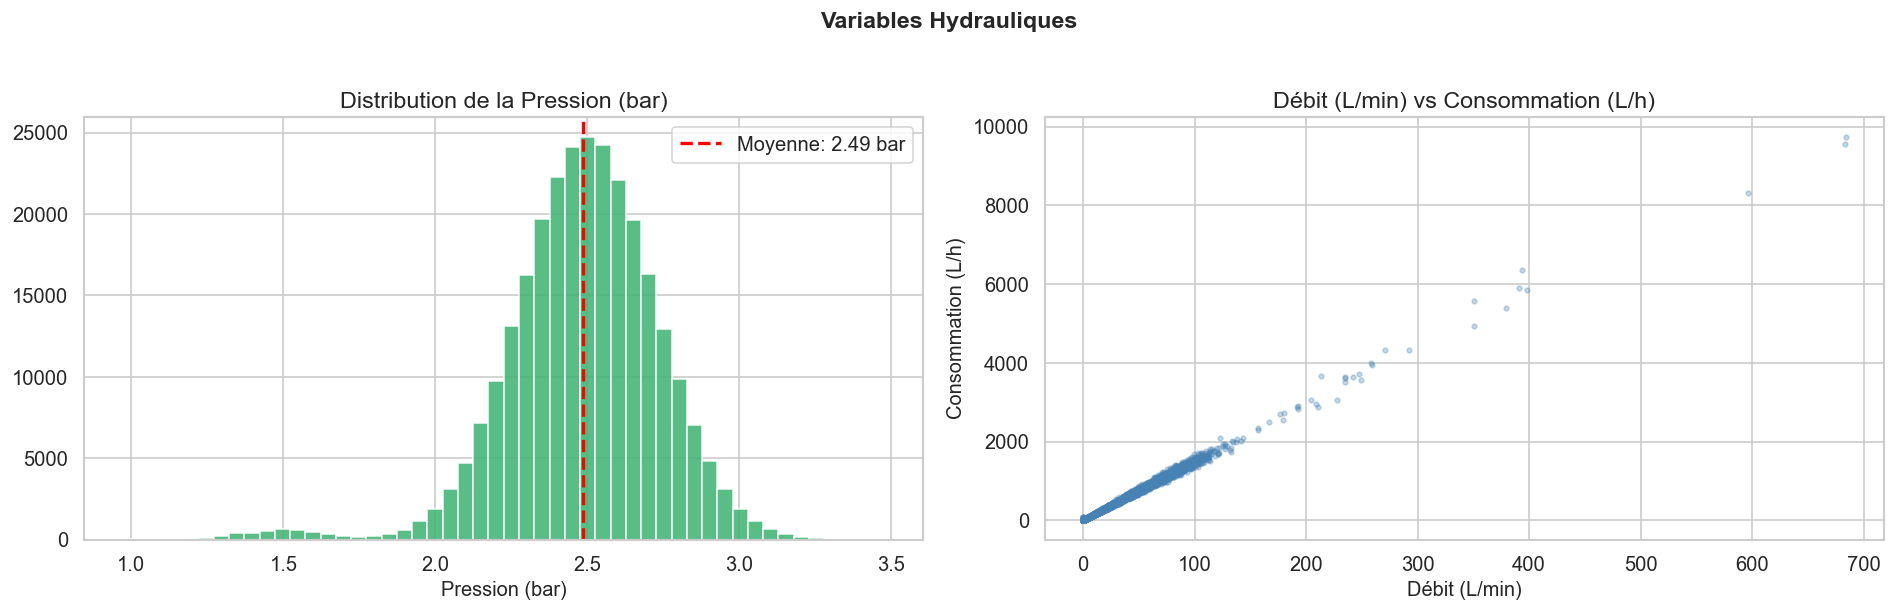

In [17]:
# ── Pression et débit ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution pression
axes[0].hist(df['pressurebar'], bins=50, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0].axvline(df['pressurebar'].mean(), color='red', linestyle='--', linewidth=2,
                label=f"Moyenne: {df['pressurebar'].mean():.2f} bar")
axes[0].set_title('Distribution de la Pression (bar)')
axes[0].set_xlabel('Pression (bar)')
axes[0].legend()

# Débit vs Consommation
sample = df.sample(min(5000, len(df)), random_state=42)
axes[1].scatter(sample['flowratelpm'], sample['consumptionliters'],
                alpha=0.3, s=8, color='steelblue')
axes[1].set_title('Débit (L/min) vs Consommation (L/h)')
axes[1].set_xlabel('Débit (L/min)')
axes[1].set_ylabel('Consommation (L/h)')

plt.suptitle('Variables Hydrauliques', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig11_variables_hydrauliques.png', bbox_inches='tight')
plt.show()

---
## 7. Événements Spéciaux — Ramadan, Festival, Holidays

📅 Répartition des événements :


,mean,median,count
event_type,,,
festival,1148.03,1151.50,3456
holiday,526.80,511.65,1152
normal,534.32,387.60,270732
ramadan,316.57,231.55,2304


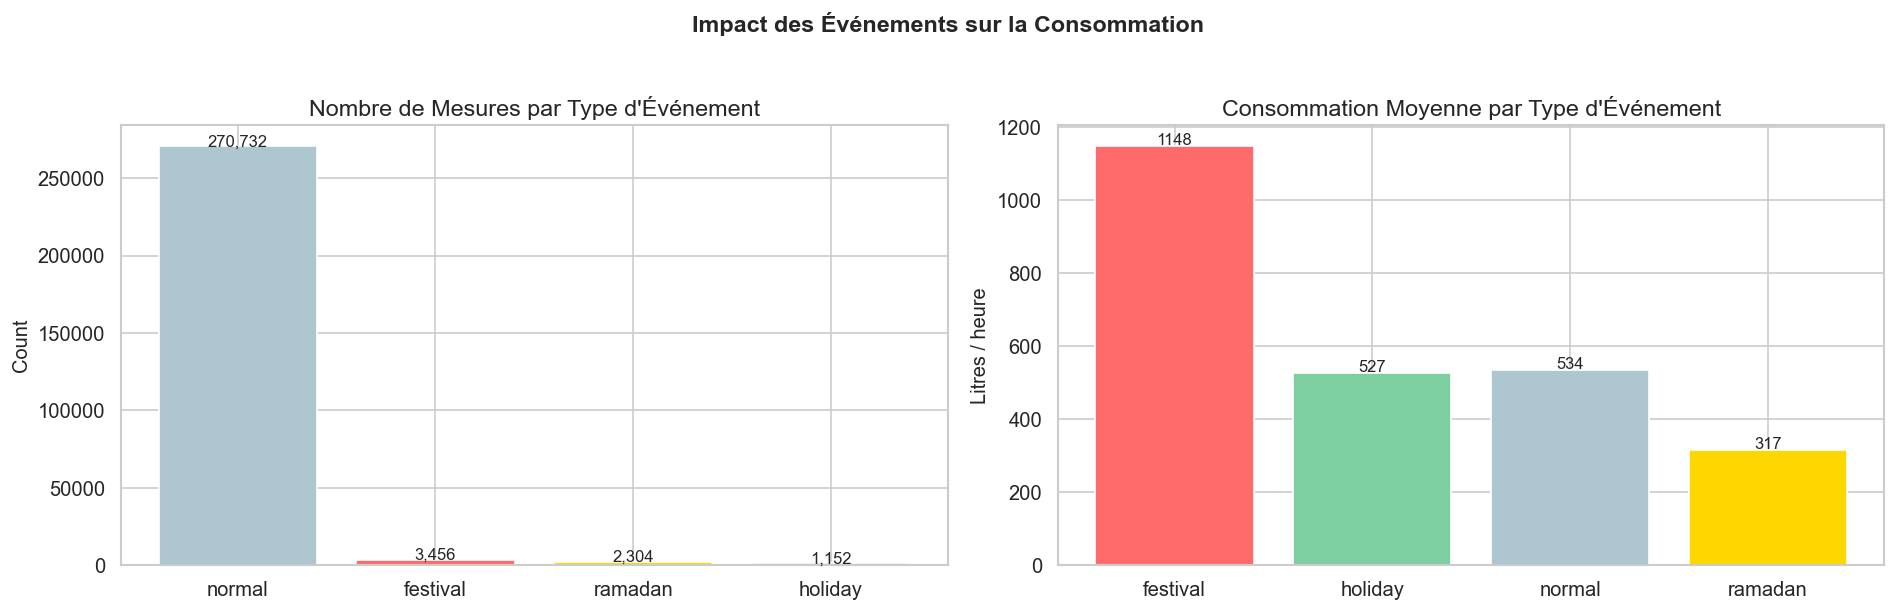

In [18]:
# ── Répartition des types d'événements ───────────────────────────────────────
event_counts = df['event_type'].value_counts()
event_conso  = df.groupby('event_type')['consumptionliters'].agg(['mean', 'median', 'count'])

print('📅 Répartition des événements :')
display(event_conso.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Nombre de mesures par événement
event_palette = {'normal': '#AEC6CF', 'ramadan': '#FFD700', 'festival': '#FF6B6B', 'holiday': '#7DCEA0'}
colors_ev = [event_palette.get(e, 'grey') for e in event_counts.index]
axes[0].bar(event_counts.index, event_counts.values, color=colors_ev, edgecolor='white')
axes[0].set_title('Nombre de Mesures par Type d\'Événement')
axes[0].set_ylabel('Count')
for i, v in enumerate(event_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=10)

# Consommation moyenne par événement
colors_ev2 = [event_palette.get(e, 'grey') for e in event_conso.index]
axes[1].bar(event_conso.index, event_conso['mean'], color=colors_ev2, edgecolor='white')
axes[1].set_title('Consommation Moyenne par Type d\'Événement')
axes[1].set_ylabel('Litres / heure')
for i, v in enumerate(event_conso['mean']):
    axes[1].text(i, v + 3, f'{v:.0f}', ha='center', fontsize=10)

plt.suptitle('Impact des Événements sur la Consommation', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig12_impact_evenements.png', bbox_inches='tight')
plt.show()

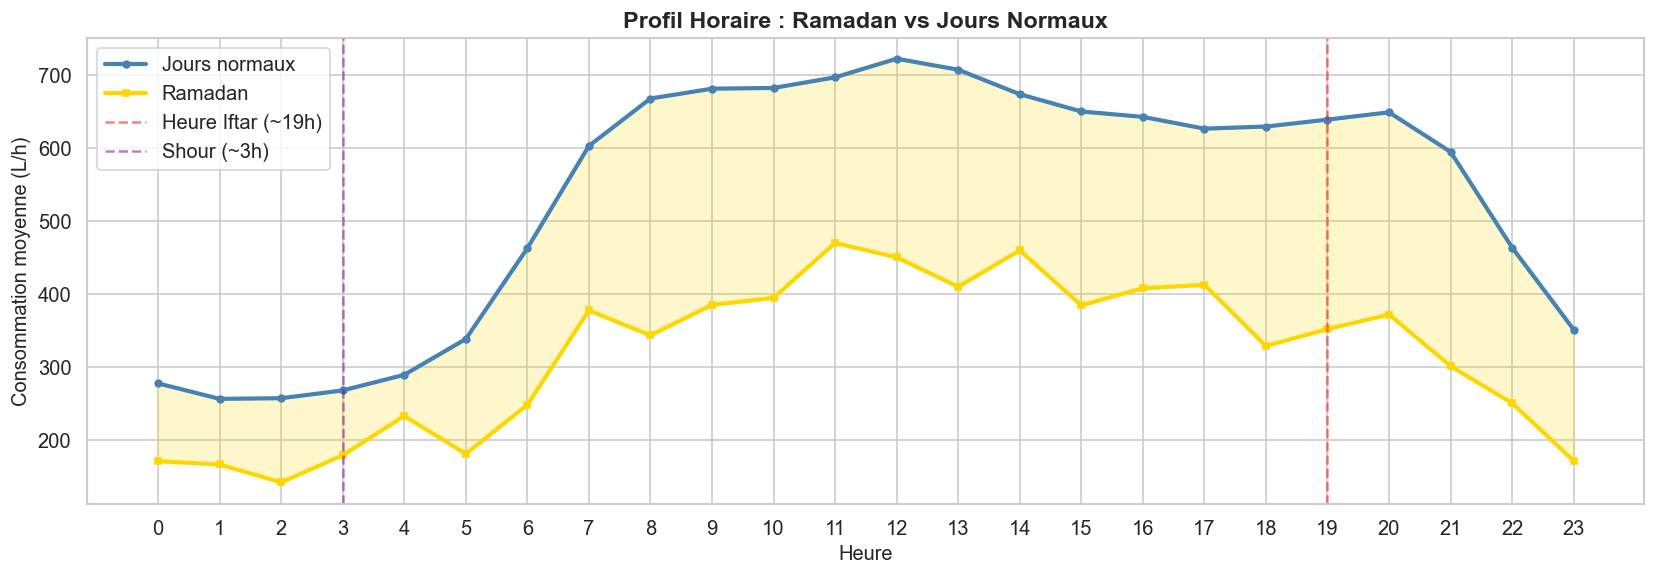

In [19]:
# ── Profil horaire pendant Ramadan vs Normal ──────────────────────────────────
if 'ramadan' in df['event_type'].values:
    ramadan_profile = df[df['event_type'] == 'ramadan'].groupby('hour')['consumptionliters'].mean()
    normal_profile  = df[df['event_type'] == 'normal'].groupby('hour')['consumptionliters'].mean()

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(normal_profile.index, normal_profile.values, label='Jours normaux',
            color='steelblue', linewidth=2.5, marker='o', markersize=4)
    ax.plot(ramadan_profile.index, ramadan_profile.values, label='Ramadan',
            color='#FFD700', linewidth=2.5, marker='s', markersize=4)
    ax.fill_between(ramadan_profile.index, normal_profile.values, ramadan_profile.values,
                    alpha=0.2, color='#FFD700')
    # Marquer l'Iftar (~19h) et Shour (~3h)
    ax.axvline(19, color='red', linestyle='--', alpha=0.5, label='Heure Iftar (~19h)')
    ax.axvline(3, color='purple', linestyle='--', alpha=0.5, label='Shour (~3h)')
    ax.set_title('Profil Horaire : Ramadan vs Jours Normaux', fontsize=14, fontweight='bold')
    ax.set_xlabel('Heure')
    ax.set_ylabel('Consommation moyenne (L/h)')
    ax.set_xticks(range(0, 24))
    ax.legend()
    plt.tight_layout()
    plt.savefig(FIG_DIR / 'fig13_ramadan_profil.png', bbox_inches='tight')
    plt.show()
else:
    print('ℹ️  Pas de données Ramadan dans le dataset')

---
## 8. Analyse des Anomalies et Fuites

🏷  Répartition des labels :
  normal       : 266,516 (95.99%)
  anomaly      :   6,972 (2.51%)
  leak         :   4,156 (1.50%)


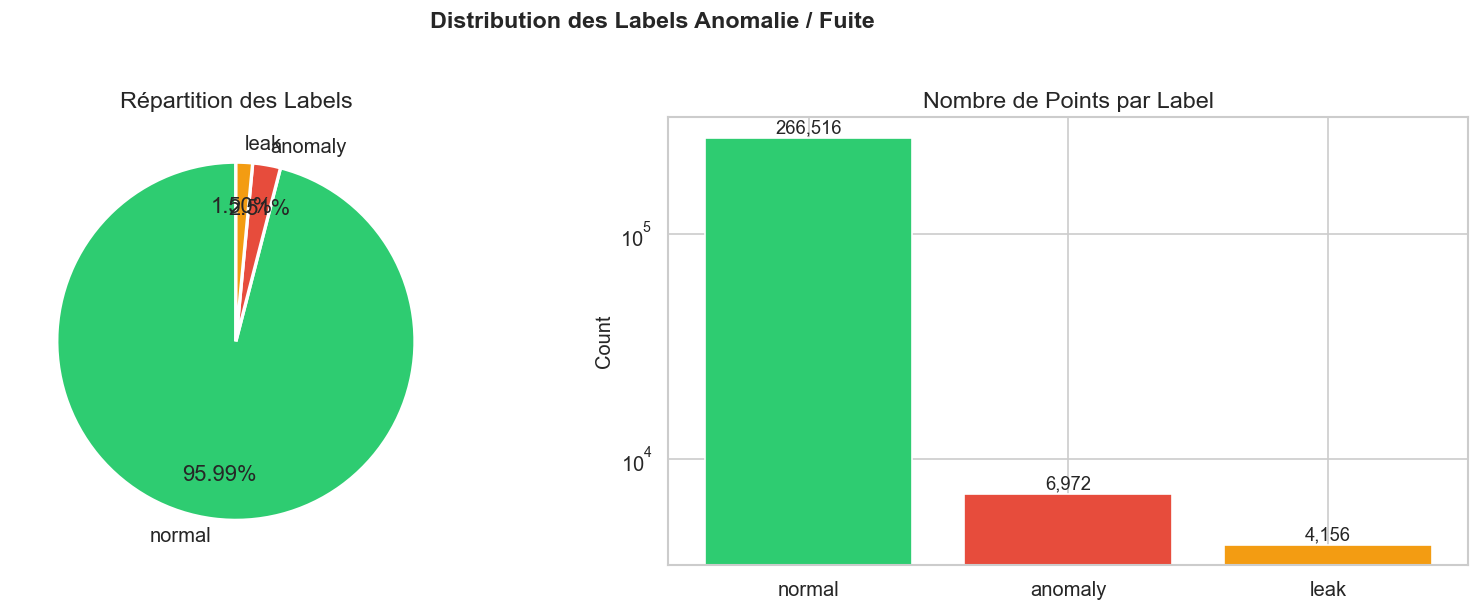

In [20]:
# ── Distribution des labels ───────────────────────────────────────────────────
label_counts = df['anomalylabel'].value_counts()
label_pct    = df['anomalylabel'].value_counts(normalize=True) * 100

print('🏷  Répartition des labels :')
for lbl in label_counts.index:
    print(f'  {lbl:<12} : {label_counts[lbl]:>7,} ({label_pct[lbl]:.2f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_colors = {'normal': '#2ECC71', 'anomaly': '#E74C3C', 'leak': '#F39C12'}
colors_lb = [label_colors.get(l, 'grey') for l in label_counts.index]

# Camembert
axes[0].pie(
    label_counts.values, labels=label_counts.index,
    autopct='%1.2f%%', colors=colors_lb,
    startangle=90, pctdistance=0.75,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
axes[0].set_title('Répartition des Labels')

# Bar
axes[1].bar(label_counts.index, label_counts.values, color=colors_lb, edgecolor='white')
axes[1].set_title('Nombre de Points par Label')
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
for i, v in enumerate(label_counts.values):
    axes[1].text(i, v * 1.05, f'{v:,}', ha='center', fontsize=11)

plt.suptitle('Distribution des Labels Anomalie / Fuite', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig14_distribution_anomalies.png', bbox_inches='tight')
plt.show()

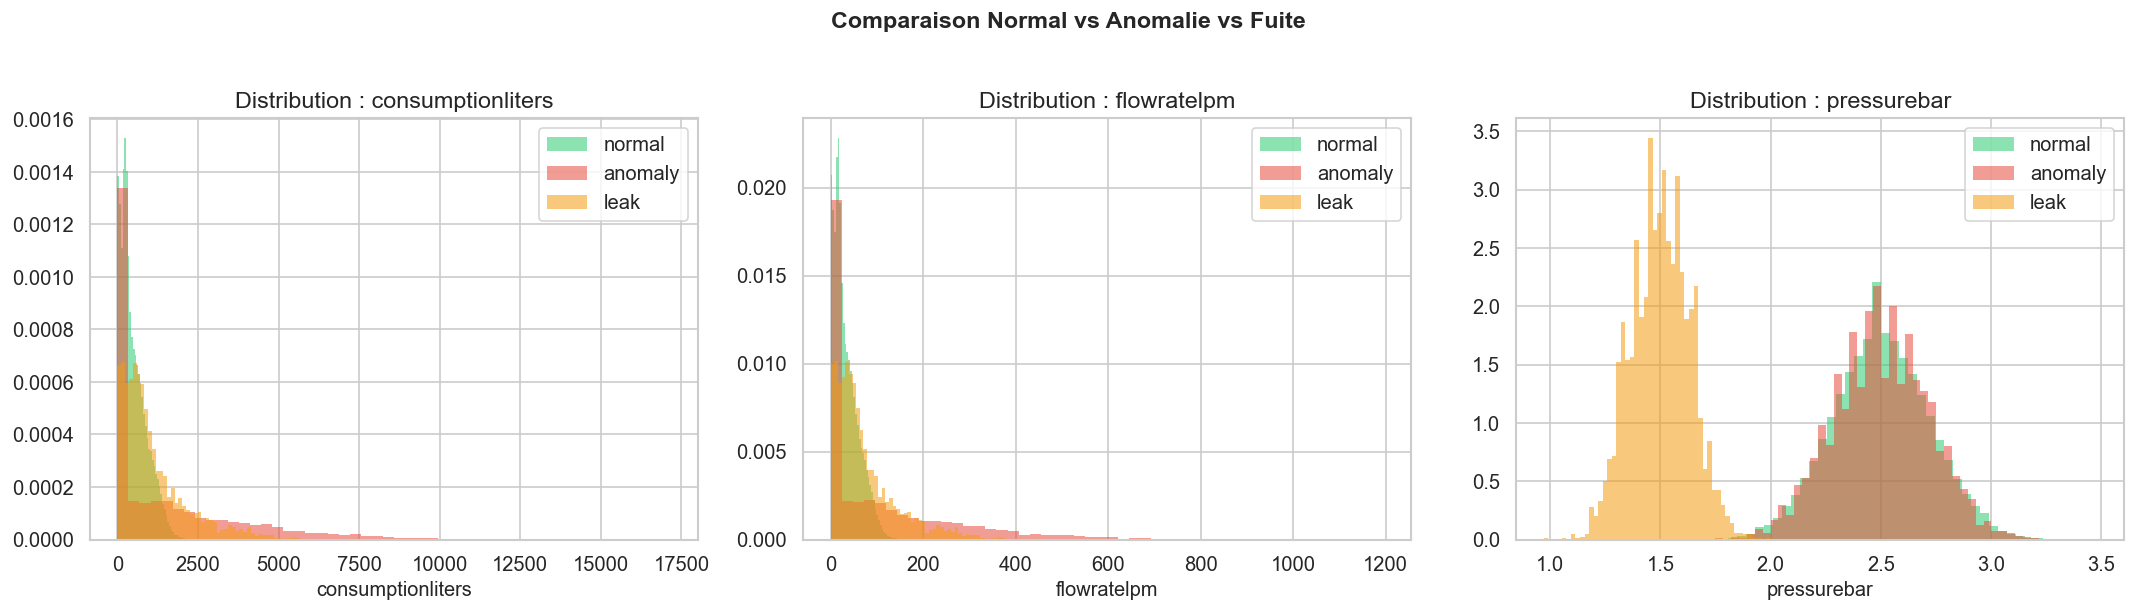

In [21]:
# ── Caractéristiques des anomalies vs normal ──────────────────────────────────
features_cmp = ['consumptionliters', 'flowratelpm', 'pressurebar']

fig, axes = plt.subplots(1, len(features_cmp), figsize=(18, 5))

for ax, feat in zip(axes, features_cmp):
    for lbl, color in label_colors.items():
        if lbl in df['anomalylabel'].values:
            data = df.loc[df['anomalylabel'] == lbl, feat].dropna()
            ax.hist(data, bins=50, alpha=0.55, color=color, label=lbl,
                    density=True, edgecolor='none')
    ax.set_title(f'Distribution : {feat}')
    ax.set_xlabel(feat)
    ax.legend()

plt.suptitle('Comparaison Normal vs Anomalie vs Fuite', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig15_comparaison_labels.png', bbox_inches='tight')
plt.show()

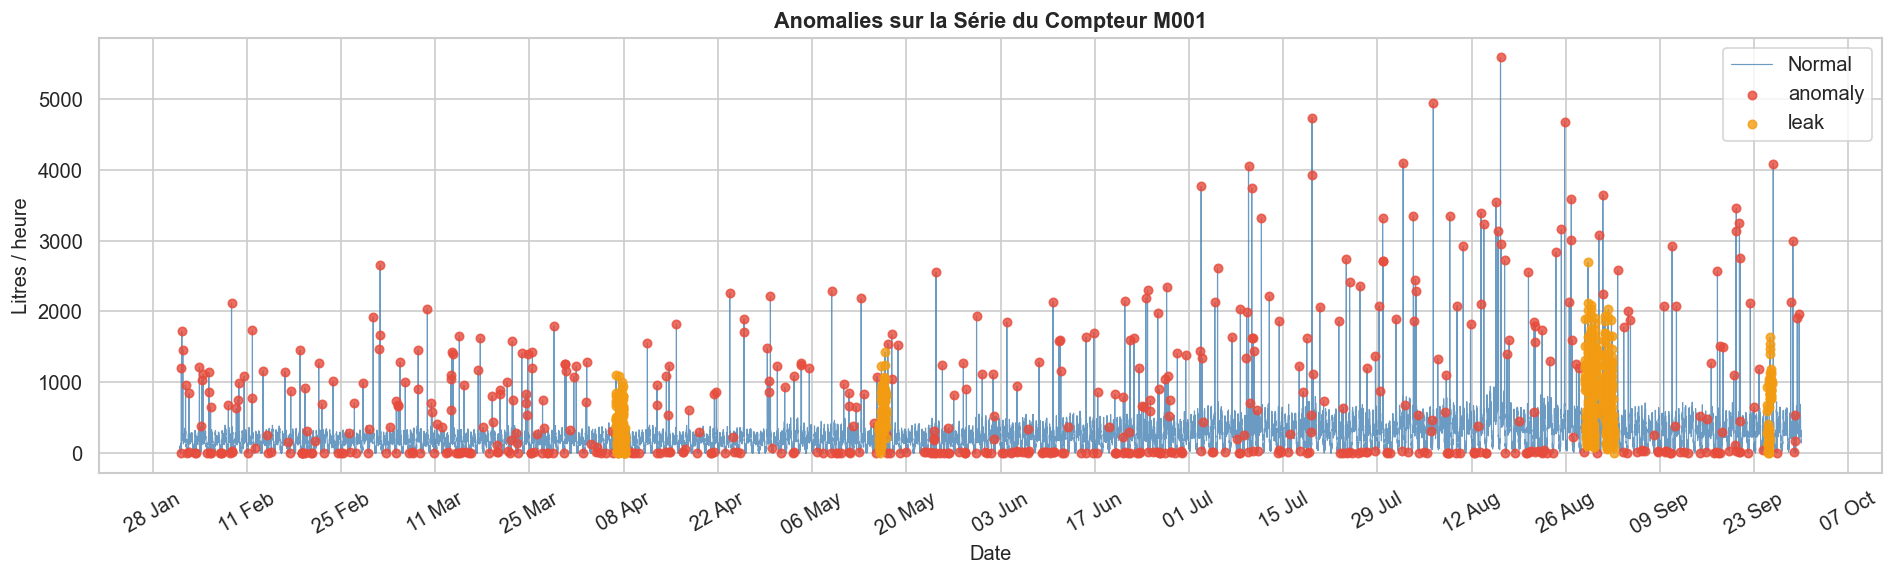

In [22]:
# ── Timeline des anomalies sur une série ──────────────────────────────────────
df_meter = df[df['meterid'] == sample_meter].copy()

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_meter['timestamp'], df_meter['consumptionliters'],
        color='steelblue', linewidth=0.7, alpha=0.8, label='Normal', zorder=1)

# Superposer les anomalies
for lbl, color in [('anomaly', '#E74C3C'), ('leak', '#F39C12')]:
    mask = df_meter['anomalylabel'] == lbl
    if mask.sum() > 0:
        ax.scatter(
            df_meter.loc[mask, 'timestamp'],
            df_meter.loc[mask, 'consumptionliters'],
            color=color, s=25, zorder=3, label=lbl, alpha=0.8
        )

ax.set_title(f'Anomalies sur la Série du Compteur {sample_meter}', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Litres / heure')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %b'))
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
plt.xticks(rotation=30)
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig16_timeline_anomalies.png', bbox_inches='tight')
plt.show()

---
## 9. Décomposition Saisonnière (STL)

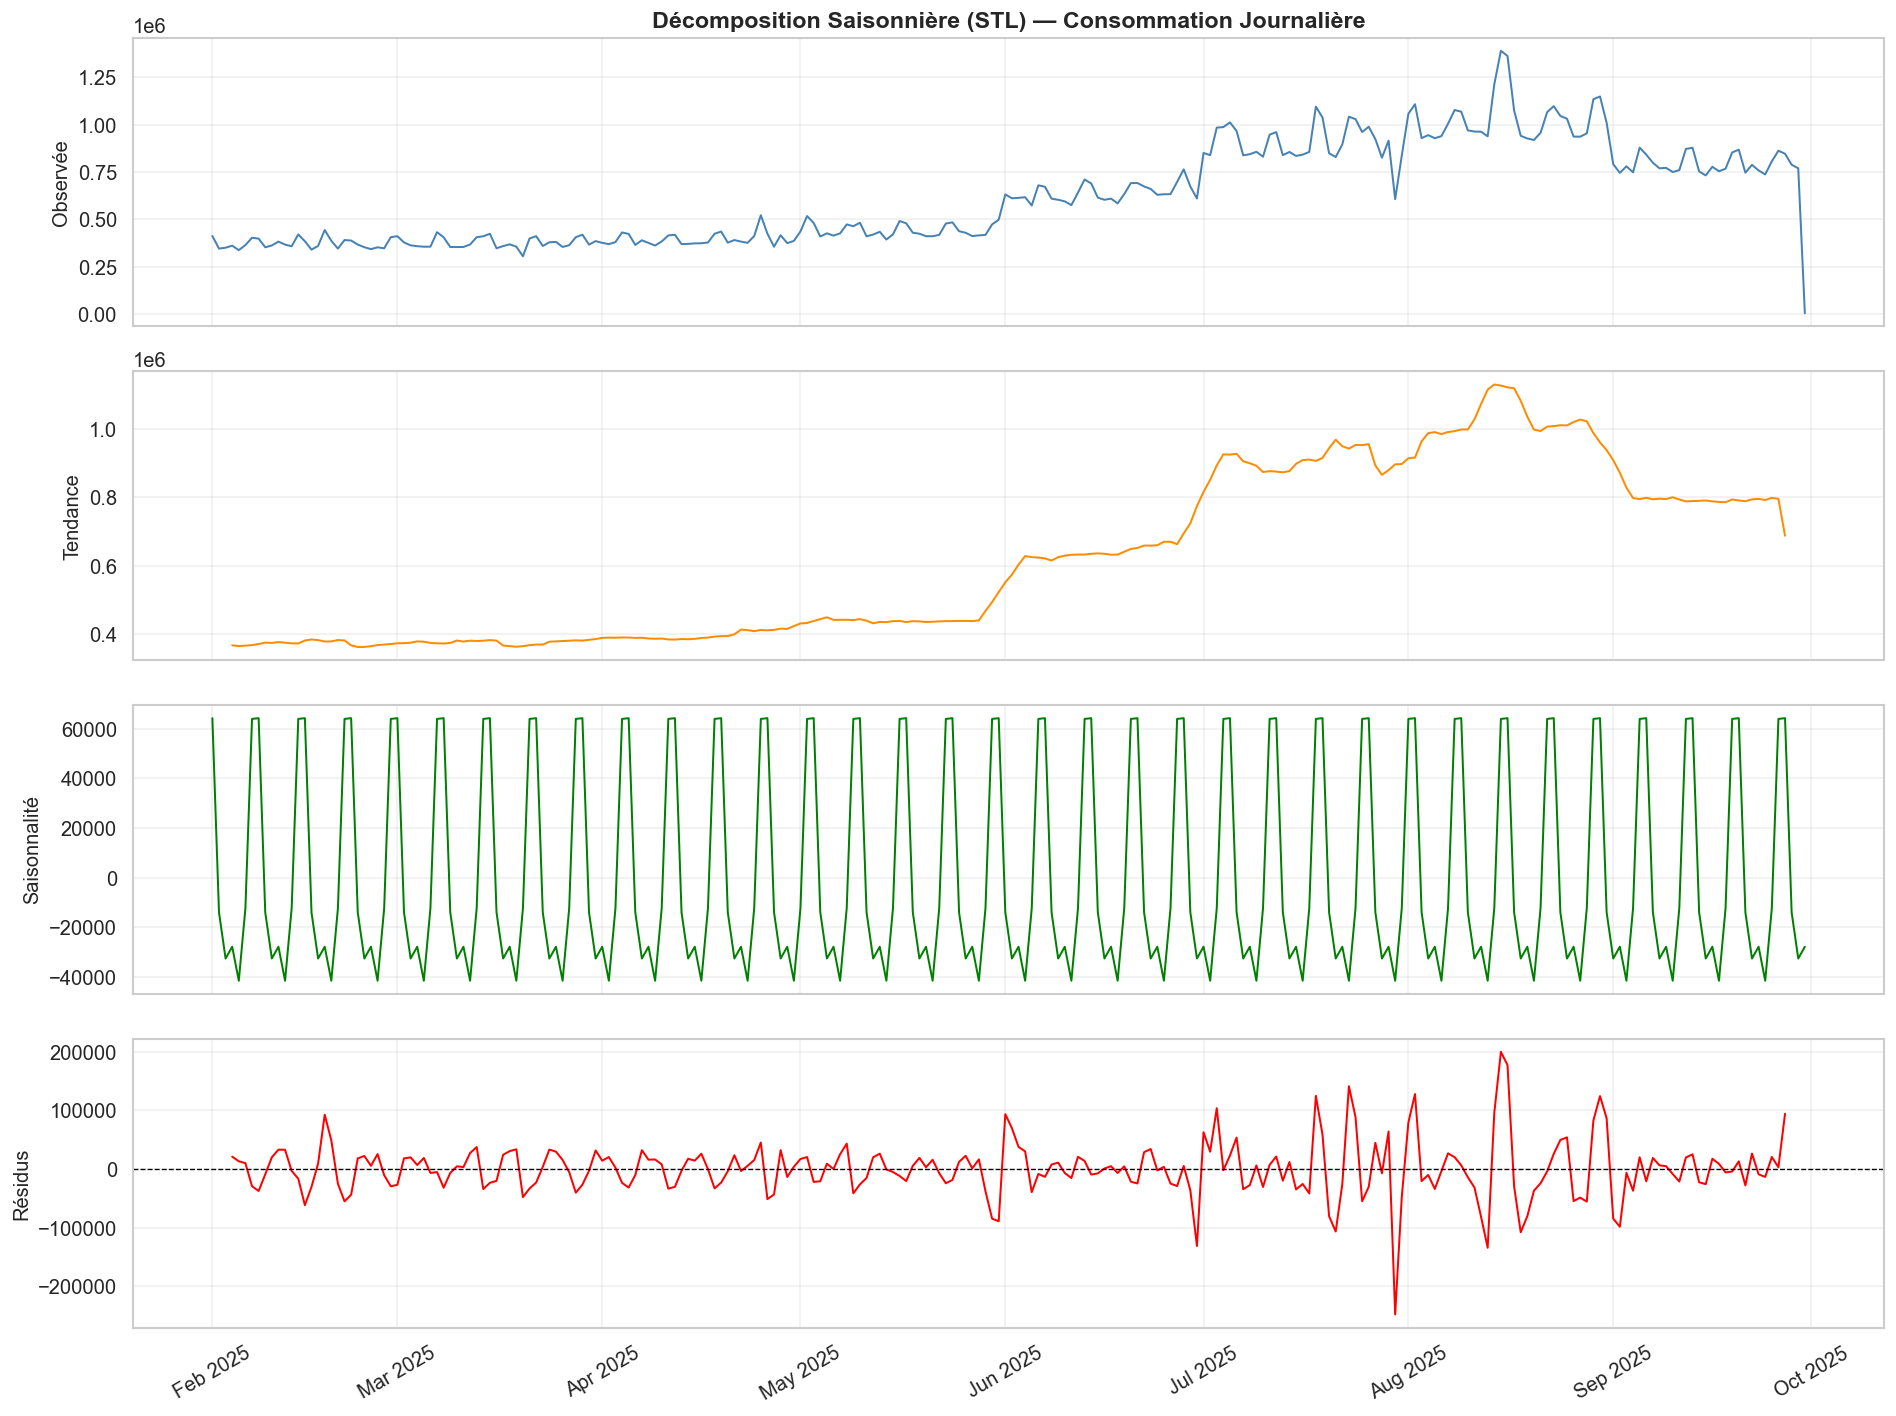

In [23]:
# ── Décomposition sur la série journalière agrégée ────────────────────────────
daily_series = (
    df.groupby(df['timestamp'].dt.date)['consumptionliters']
      .sum()
)
daily_series.index = pd.to_datetime(daily_series.index)
daily_series = daily_series.sort_index()

decomp = seasonal_decompose(daily_series, model='additive', period=7)

fig, axes = plt.subplots(4, 1, figsize=(16, 12), sharex=True)
components = [
    (decomp.observed,  'Observée',   'steelblue'),
    (decomp.trend,     'Tendance',   'darkorange'),
    (decomp.seasonal,  'Saisonnalité', 'green'),
    (decomp.resid,     'Résidus',    'red'),
]
for ax, (data, title, color) in zip(axes, components):
    ax.plot(data, color=color, linewidth=1.2)
    ax.set_ylabel(title)
    if title == 'Résidus':
        ax.axhline(0, color='black', linestyle='--', linewidth=0.8)
    ax.grid(True, alpha=0.3)

axes[0].set_title('Décomposition Saisonnière (STL) — Consommation Journalière',
                  fontsize=14, fontweight='bold')
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig17_decomposition_saisonniere.png', bbox_inches='tight')
plt.show()

---
## 10. Autocorrélation (ACF / PACF) — Guide pour SARIMA

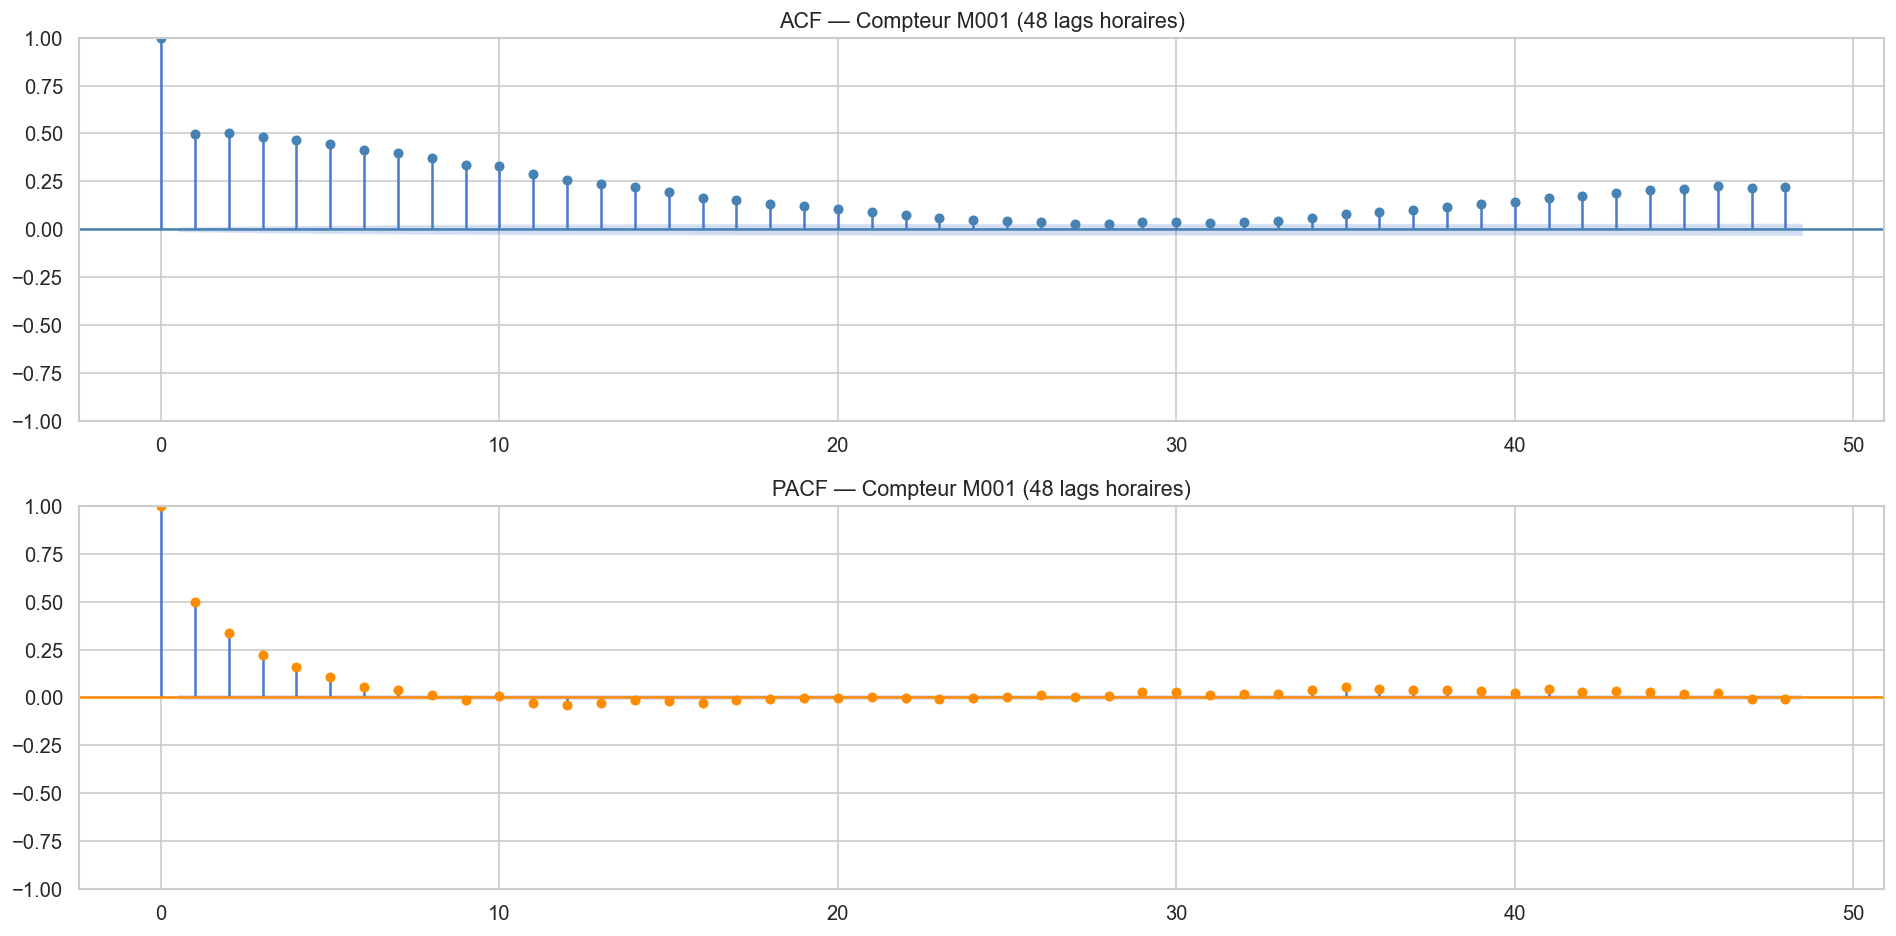

In [24]:
# ── ACF et PACF sur la série horaire d'un compteur ───────────────────────────
ts_meter = df[df['meterid'] == sample_meter].set_index('timestamp')['consumptionliters']

fig, axes = plt.subplots(2, 1, figsize=(16, 8))
plot_acf(ts_meter,  lags=48, ax=axes[0], alpha=0.05, color='steelblue')
plot_pacf(ts_meter, lags=48, ax=axes[1], alpha=0.05, color='darkorange', method='ywm')
axes[0].set_title(f'ACF — Compteur {sample_meter} (48 lags horaires)', fontsize=13)
axes[1].set_title(f'PACF — Compteur {sample_meter} (48 lags horaires)', fontsize=13)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig18_acf_pacf.png', bbox_inches='tight')
plt.show()

In [25]:
# ── Test de stationnarité (ADF) ───────────────────────────────────────────────
adf_result = adfuller(ts_meter.dropna(), autolag='AIC')
print('=== Test de Stationnarité (ADF) ===')
print(f'  Statistique ADF : {adf_result[0]:.4f}')
print(f'  p-value         : {adf_result[1]:.6f}')
print(f'  Nb de lags      : {adf_result[2]}')
print(f'  N observations  : {adf_result[3]}')
print('  Valeurs critiques :')
for key, val in adf_result[4].items():
    print(f'    {key}: {val:.4f}')
if adf_result[1] < 0.05:
    print('\n✅ La série est STATIONNAIRE (p < 0.05) → pas de différenciation nécessaire')
else:
    print('\n⚠️  La série est NON STATIONNAIRE (p ≥ 0.05) → différenciation recommandée')

=== Test de Stationnarité (ADF) ===
  Statistique ADF : -11.8770
  p-value         : 0.000000
  Nb de lags      : 47
  N observations  : 23089
  Valeurs critiques :
    1%: -3.4306
    5%: -2.8617
    10%: -2.5668

✅ La série est STATIONNAIRE (p < 0.05) → pas de différenciation nécessaire


---
## 11. Carte Géographique des Compteurs

In [26]:
# ── Position et consommation moyenne par compteur ─────────────────────────────
if 'latitude' in df.columns and 'longitude' in df.columns:
    meter_geo = (
        df.groupby('meterid')
          .agg(
              latitude  = ('latitude', 'first'),
              longitude = ('longitude', 'first'),
              zone      = ('zone', 'first'),
              quartier  = ('quartier', 'first') if 'quartier' in df.columns else ('meterid', 'first'),
              mean_conso = ('consumptionliters', 'mean'),
              anomaly_rate = ('anomalylabel', lambda x: (x != 'normal').mean() * 100)
          )
          .reset_index()
    )

    zone_color_map = {'residential': 'blue', 'tourist': 'orange', 'industrial': 'red'}

    fig = px.scatter_mapbox(
        meter_geo,
        lat='latitude', lon='longitude',
        color='zone',
        size='mean_conso',
        hover_name='meterid',
        hover_data={'mean_conso': ':.0f', 'anomaly_rate': ':.1f', 'quartier': True},
        color_discrete_map=zone_color_map,
        title='Carte des Compteurs — Grand Agadir',
        mapbox_style='open-street-map',
        zoom=11,
        height=550
    )
    fig.update_layout(margin={'r':0,'t':40,'l':0,'b':0})
    fig.show()
    fig.write_html(str(FIG_DIR / 'fig19_carte_compteurs.html'))
    print('✅ Carte sauvegardée en HTML interactif')
else:
    print('⚠️  Colonnes latitude/longitude non disponibles')

✅ Carte sauvegardée en HTML interactif


---
## 12. Analyse du Split Train / Test

📊 Split temporel : 2025-08-15
  Train : 224,640 lignes (80.9%)
        : 2025-02-01 → 2025-08-14
  Test  :  53,004 lignes (19.1%)
        : 2025-08-15 → 2025-09-30


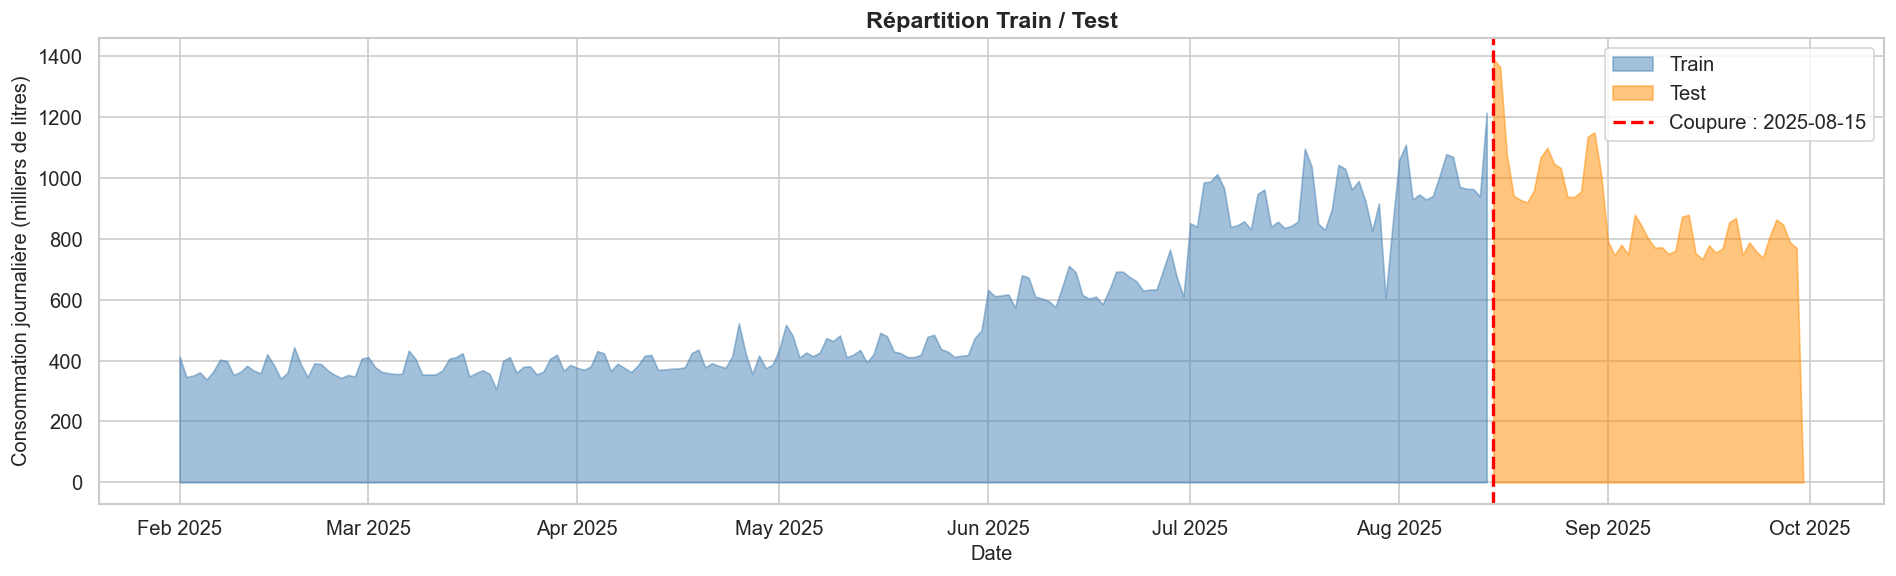

In [27]:
# ── Split temporel (80% train / 20% test) ────────────────────────────────────
SPLIT_DATE = pd.Timestamp('2025-08-15')

df_train = df[df['timestamp'] < SPLIT_DATE]
df_test  = df[df['timestamp'] >= SPLIT_DATE]

print(f'📊 Split temporel : {SPLIT_DATE.date()}')
print(f'  Train : {len(df_train):>7,} lignes ({len(df_train)/len(df)*100:.1f}%)')
print(f'        : {df_train.timestamp.min().date()} → {df_train.timestamp.max().date()}')
print(f'  Test  : {len(df_test):>7,} lignes ({len(df_test)/len(df)*100:.1f}%)')
print(f'        : {df_test.timestamp.min().date()} → {df_test.timestamp.max().date()}')

# Visualisation
daily_train = df_train.groupby(df_train['timestamp'].dt.date)['consumptionliters'].sum()
daily_test  = df_test.groupby(df_test['timestamp'].dt.date)['consumptionliters'].sum()
daily_train.index = pd.to_datetime(daily_train.index)
daily_test.index  = pd.to_datetime(daily_test.index)

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(daily_train.index, daily_train.values / 1000, alpha=0.5, color='steelblue', label='Train')
ax.fill_between(daily_test.index, daily_test.values / 1000, alpha=0.5, color='darkorange', label='Test')
ax.axvline(SPLIT_DATE, color='red', linestyle='--', linewidth=2, label=f'Coupure : {SPLIT_DATE.date()}')
ax.set_title('Répartition Train / Test', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Consommation journalière (milliers de litres)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig20_split_train_test.png', bbox_inches='tight')
plt.show()

---
## 13. Récapitulatif & Insights pour la Modélisation

In [28]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║             SYNTHÈSE EDA — INSIGHTS POUR LA MODÉLISATION            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📐 DATASET                                                          ║
║  • 277 644 observations horaires, 12 compteurs, 3 zones             ║
║  • Période : 01/02/2025 → 30/09/2025 (241 jours)                   ║
║  • Aucune valeur manquante, aucun doublon                            ║
║                                                                      ║
║  📈 PATTERNS TEMPORELS DÉTECTÉS                                      ║
║  • Saisonnalité journalière forte (pic matin & soir)                ║
║  • Saisonnalité hebdomadaire (week-end différent)                   ║
║  • Effet estival (Juil–Sep) : +20–30% vs autres mois               ║
║  → Recommandation : SARIMA(p,d,q)(P,D,Q)[24] + Prophet            ║
║                                                                      ║
║  🌡  VARIABLES UTILES                                                ║
║  • Température : corrélation positive avec consommation             ║
║  • Pluie : impact négligeable (climat semi-aride Agadir)            ║
║  • Débit & pression : indicateurs clés pour la détection           ║
║  → XGBoost features : lags, temp, heure, jour, mois, event         ║
║                                                                      ║
║  🎪 ÉVÉNEMENTS                                                       ║
║  • Ramadan : pic Iftar (~19h), forte baisse diurne                 ║
║  • Festival : +15% consommation touristique                         ║
║  → Prophet : ajouter event_type comme regressor                    ║
║                                                                      ║
║  🔴 ANOMALIES                                                        ║
║  • Normal : 95.99% | Anomalie : 2.51% | Fuite : 1.50%             ║
║  • Déséquilibre de classes → utiliser class_weight ou SMOTE       ║
║  • Fuites : pression chute + débit anormalement stable             ║
║  → Isolation Forest + LSTM-AE + seuil 3-sigma sur résidus         ║
║                                                                      ║
║  ✂️  SPLIT                                                           ║
║  • Train : 224 640 (80.9%) | Test : 53 004 (19.1%)                ║
║  • Coupure : 15/08/2025 (respecte la temporalité)                  ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print('\n🗂  Figures sauvegardées dans : reports/figures/')
figs = sorted(FIG_DIR.glob('fig*.png')) + sorted(FIG_DIR.glob('fig*.html'))
for f in figs:
    print(f'  • {f.name}')


╔══════════════════════════════════════════════════════════════════════╗
║             SYNTHÈSE EDA — INSIGHTS POUR LA MODÉLISATION            ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  📐 DATASET                                                          ║
║  • 277 644 observations horaires, 12 compteurs, 3 zones             ║
║  • Période : 01/02/2025 → 30/09/2025 (241 jours)                   ║
║  • Aucune valeur manquante, aucun doublon                            ║
║                                                                      ║
║  📈 PATTERNS TEMPORELS DÉTECTÉS                                      ║
║  • Saisonnalité journalière forte (pic matin & soir)                ║
║  • Saisonnalité hebdomadaire (week-end différent)                   ║
║  • Effet estival (Juil–Sep) : +20–30% vs autres mois               ║
║  → Recommandation : SARIMA(p,d,q)(P,D,Q)[24] + Prophet    

In [29]:
# ── Corrections avant sauvegarde ────────────────────────────────────────────
# Correction 1 : drop rainfall (colinéaire avec month, r=0.90)
df = df.drop(columns=['rainfall'])
print(f'\u2705 Correction 1 : colonne rainfall supprimée (colinéaire avec month r=0.90)')
print(f'   Colonnes restantes ({len(df.columns)}) : {list(df.columns)}')

# Correction 2 : exclure le 30 septembre (journée incomplète)
LAST_FULL_DAY = pd.Timestamp('2025-09-29')
rows_before = len(df)
df = df[df['timestamp'].dt.date <= LAST_FULL_DAY.date()].copy()
print(f'\n\u2705 Correction 2 : 30 septembre exclu (journée incomplète)')
print(f'   Lignes supprimées : {rows_before - len(df):,}')
print(f'   Dataset final     : {len(df):,} lignes')

# ── Sauvegarde du split train / test ─────────────────────────────────────────
SPLIT_DATE = pd.Timestamp('2025-08-15')

df_train = df[df['timestamp'] < SPLIT_DATE].copy()
df_test  = df[df['timestamp'] >= SPLIT_DATE].copy()

DATA_DIR = Path('../data')
DATA_DIR.mkdir(exist_ok=True)

df_train.to_csv(DATA_DIR / 'train.csv', index=False)
df_test.to_csv(DATA_DIR  / 'test.csv',  index=False)

print(f'\n\u2705 Fichiers sauvegard\u00e9s :')
print(f'   \u2192 data/train.csv  :  {len(df_train):>7,} lignes  '
      f'({df_train.timestamp.min().date()} \u2192 {df_train.timestamp.max().date()})')
print(f'   \u2192 data/test.csv   :  {len(df_test):>7,} lignes  '
      f'({df_test.timestamp.min().date()} \u2192 {df_test.timestamp.max().date()})')
print(f'   \u2192 Ratio train/test : {len(df_train)/len(df)*100:.1f}% / {len(df_test)/len(df)*100:.1f}%')
print(f'   \u2192 Colonnes ({len(df_train.columns)}) : {list(df_train.columns)}')

✅ Correction 1 : colonne rainfall supprimée (colinéaire avec month r=0.90)
   Colonnes restantes (19) : ['timestamp', 'meterid', 'zone', 'quartier', 'latitude', 'longitude', 'consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'hour', 'dayofweek', 'month', 'isweekend', 'season', 'household_size', 'event_type', 'anomalylabel', 'temp_bin']

✅ Correction 2 : 30 septembre exclu (journée incomplète)
   Lignes supprimées : 12
   Dataset final     : 277,632 lignes

✅ Fichiers sauvegardés :
   → data/train.csv  :  224,640 lignes  (2025-02-01 → 2025-08-14)
   → data/test.csv   :   52,992 lignes  (2025-08-15 → 2025-09-29)
   → Ratio train/test : 80.9% / 19.1%
   → Colonnes (19) : ['timestamp', 'meterid', 'zone', 'quartier', 'latitude', 'longitude', 'consumptionliters', 'flowratelpm', 'pressurebar', 'temperaturec', 'hour', 'dayofweek', 'month', 'isweekend', 'season', 'household_size', 'event_type', 'anomalylabel', 'temp_bin']


In [30]:
print('\n\U0001f3c1 EDA terminée. Prochaine étape \u2192 02_prediction.ipynb')


🏁 EDA terminée. Prochaine étape → 02_prediction.ipynb
